<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP5/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_5_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 - Aprendizaje en redes neuronales artificiales

---



# Ejercicio 1: Clasificación automática de prendas de vestir — Fashion MNIST



**Dataset:** Fashion MNIST — 70.000 imágenes 28×28 px, escala de grises, 10 categorías  
**Framework:** TensorFlow / Keras (Sequential API)  
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** 14/05/26

---

> **Guía de lectura.** El notebook sigue una progresión deliberada:
> construimos la red más simple posible → observamos su comportamiento →
> identificamos problemas (underfitting, overfitting) → los resolvemos uno a uno
> con herramientas concretas (callbacks, regularización, exploración de arquitecturas).
> Cada sección parte de una hipótesis explícita y cierra con una conclusión basada en lo observado.

---

## 0. Contexto del problema

**Situación:** Una cadena de tiendas de indumentaria necesita automatizar la catalogación
de productos a partir de imágenes. El proceso manual (un operario asigna la categoría de
cada prenda) es costoso y propenso a errores cuando se manejan miles de productos por semana.

**Propuesta:** Entrenar una red neuronal densa que, dada la imagen de una prenda,
determine automáticamente su categoría (10 clases).

**Dataset de partida:** Fashion MNIST
- 70.000 imágenes en escala de grises, 28×28 píxeles
- 60.000 entrenamiento / 10.000 test
- 10 categorías balanceadas: Remera, Pantalón, Pullover, Vestido, Abrigo, Sandalia, Camisa, Zapatilla, Bolso, Botín
- Imágenes centradas y sobre fondo uniforme → condiciones controladas, ideales para un prototipo

**Pregunta central:** ¿Puede una red densa (sin convolución, operando sobre píxeles
aplanados) clasificar prendas con precisión suficiente para automatizar el proceso?

---

## 1. Configuración del entorno y reproducibilidad

Antes de escribir una sola línea de modelo, fijamos las semillas aleatorias. Esto es
**fundamental** para que el notebook sea reproducible: TensorFlow y NumPy usan generadores
de números aleatorios internos para inicializar los pesos de la red, mezclar los datos en
cada época (shuffling) y aplicar Dropout. Sin fijar estas semillas, dos ejecuciones
del mismo código pueden dar resultados distintos, lo que impide comparar experimentos.

También importamos todas las dependencias en un único bloque al inicio del notebook:
esto hace explícitas las dependencias externas y evita errores de "nombre no definido"
si las celdas se ejecutan fuera de orden.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd

# ── Semillas para reproducibilidad ───────────────────────────────────────────
# tf.random.set_seed controla la inicialización de pesos en Keras.
# np.random.seed controla shuffling y otras operaciones de NumPy.
# Ambas son necesarias porque Keras usa internamente ambas fuentes de aleatoriedad.
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : False


## 2. Carga y exploración del dataset

### ¿Por qué explorar antes de modelar?

Antes de definir cualquier arquitectura, necesitamos entender qué estamos procesando:
el tipo de dato (enteros, flotantes), el rango de valores (¿normalizado o no?), la
distribución de clases (¿balanceado o desbalanceado?), y cómo se ven visualmente las imágenes.

Estas preguntas no son triviales: la distribución de clases determina si podemos confiar
en el accuracy como métrica única. El rango de valores determina si necesitamos normalizar.
La dificultad visual de distinguir clases anticipa qué errores va a cometer el modelo.

Fashion MNIST es un dataset **interno a Keras**, no requiere descarga manual.

In [10]:
# load_data() devuelve dos tuplas: (X_train, y_train) y (X_test, y_test).
# X: arrays de imágenes 28×28 con valores uint8 en [0, 255]
# y: etiquetas enteras en [0, 9] que corresponden a cada categoría
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()

# Mapeamos cada índice numérico a su nombre en español
CLASS_NAMES = [
    'Remera/Top', 'Pantalón', 'Pullover', 'Vestido', 'Abrigo',
    'Sandalia',   'Camisa',   'Zapatilla', 'Bolso',  'Botín'
]

print(f"Train : {X_train_raw.shape}  — dtype={X_train_raw.dtype}")
print(f"Test  : {X_test_raw.shape}")
print(f"Rango de píxeles: [{X_train_raw.min()}, {X_train_raw.max()}]")
print()

# Verificar balance de clases:
print("Distribución en train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    barra = '█' * (c // 500)
    print(f"  [{u}] {CLASS_NAMES[u]:<12}: {c:,}  {barra}")
print()
print("→ Dataset perfectamente balanceado: 6.000 imágenes por clase.")
print("  En este caso, accuracy es una métrica confiable.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (60000, 28, 28)  — dtype=uint8
Test  : (10000, 28, 28)
Rango de píxeles: [0, 255]

Distribución en train:
  [0] Remera/Top  : 6,000  ████████████
  [1] Pantalón    : 6,000  ████████████
  [2] Pullover    : 6,000  ████████████
  [3] Vestido     : 6,000  ████████████
  [4] Abrigo      : 6,000  ████████████
  [5] Sandalia    : 6,000  ████████████
  [6] Camisa      : 6,000  ████████████
  [7] Zapatilla   : 6,000  ████████████
  [8] Bolso       : 6,000  ████████████
  [9] Botín       : 6,000  ████████████

→ Dataset perfectamente balanceado: 6.000 imágenes por clase.
  En este caso, accuracy es una métrica confiable.


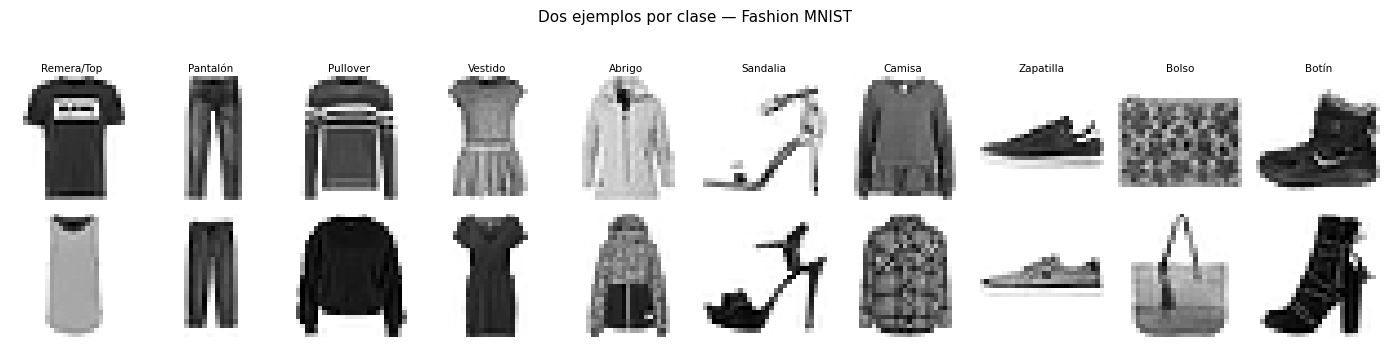

In [11]:
# Visualizamos dos ejemplos de cada clase.
# Objetivo: entender la dificultad visual del problema antes de modelar.
# Pregunta clave: ¿son todas las clases igualmente distinguibles a simple vista?

n_cols = 10  # una columna por clase
fig, axes = plt.subplots(2, n_cols, figsize=(14, 3.5))

for cls_idx in range(n_cols):
    samples = np.where(y_train == cls_idx)[0][:2]
    for row, idx in enumerate(samples):
        ax = axes[row, cls_idx]
        ax.imshow(X_train_raw[idx], cmap='gray_r')
        ax.axis('off')
        if row == 0:
            ax.set_title(CLASS_NAMES[cls_idx], fontsize=7.5, pad=3)

plt.suptitle("Dos ejemplos por clase — Fashion MNIST", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

> **Observación visual:** Ya a simple vista se pueden anticipar las clases más difíciles
> de distinguir:
> - **Remera/Top vs Camisa**: ambas son prendas de torso superiores con forma similar.
> - **Pullover vs Abrigo**: son prendas superpuestas de silueta parecida.
> - **Zapatilla vs Botín**: formas de calzado relativamente similares en silueta.
>
> Estas confusiones son esperables y las veremos reflejadas en la matriz de confusión
> al evaluar el modelo final.

## 3. Preprocesamiento

### ¿Por qué normalizar?

Las redes neuronales aprenden ajustando pesos a través del gradiente. Si los valores
de entrada son grandes (como píxeles en [0, 255]), el gradiente también puede ser
grande e inestable, dificultando la convergencia.

La solución estándar es llevar los valores al rango **[0, 1]** dividiendo por 255:

$$x_{\text{norm}} = \frac{x}{255}$$

Esto no modifica la *información* de la imagen, solo su escala numérica. Las funciones
de activación como ReLU o Sigmoid también operan mejor en rangos acotados.

In [12]:
# El cast a float32 es implícito en la división; no hace falta cast explícito.
# Hacemos esto TANTO en train como en test usando el mismo factor (255),
# ya que en producción nunca podemos "ver" el test para calcular estadísticas.
X_train = X_train_raw / 255.0
X_test  = X_test_raw  / 255.0

print(f"Train — shape: {X_train.shape}  dtype: {X_train.dtype}")
print(f"Rango post-normalización: [{X_train.min():.1f}, {X_train.max():.1f}]")
print()
print("Las imágenes siguen siendo 28×28. La primera capa Dense recibirá")
print("un vector de 784 valores (aplanado por la capa Flatten).")
print("Nota: la capa Flatten no aprende nada — solo reordena los datos.")

Train — shape: (60000, 28, 28)  dtype: float64
Rango post-normalización: [0.0, 1.0]

Las imágenes siguen siendo 28×28. La primera capa Dense recibirá
un vector de 784 valores (aplanado por la capa Flatten).
Nota: la capa Flatten no aprende nada — solo reordena los datos.


## 4. Modelo base (punto de partida)

### Estrategia de diseño: empezar simple

Antes de explorar arquitecturas complejas, construimos la red **más simple posible**:
una capa oculta de 128 neuronas. Esto nos da una referencia concreta (baseline) contra
la cual medir cualquier mejora posterior.

**Decisiones de diseño del baseline:**

| Decisión | Elección | Justificación |
|---|---|---|
| Entrada | `Flatten` (28×28 → 784) | La red densa no procesa matrices, necesita vectores |
| Activación oculta | `ReLU` | Rápida, no sufre vanishing gradient, estándar |
| Activación salida | `Softmax` | Produce probabilidades (suman 1) para 10 clases |
| Neuronas de salida | `10` | Una por clase — obligatorio |
| Loss | `sparse_categorical_crossentropy` | Clasificación multi-clase con etiquetas enteras |
| Optimizador | `Adam` | LR adaptativa, buena elección por defecto |

**¿Por qué `sparse_categorical_crossentropy` y no `categorical_crossentropy`?**
Porque nuestras etiquetas son enteros (0, 1, 2, ..., 9), no vectores one-hot.
`sparse_` permite usar etiquetas enteras directamente, ahorrando el paso de
conversión y memoria.

In [13]:
# ── Función auxiliar para graficar curvas de entrenamiento ────────────────────
# Esta función se reutiliza en todos los experimentos de esta experiencia.
# Grafica pérdida (loss) y accuracy tanto para train como para validación
# (si está disponible). La separación train/val es la herramienta de diagnóstico
# principal: si train mejora pero val no, hay overfitting.

def plot_history(history, title='Curvas de entrenamiento'):
    has_val = 'val_loss' in history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.history['loss']) + 1)

    # Gráfica de pérdida
    axes[0].plot(epochs, history.history['loss'], 'b-o', ms=4, label='Train')
    if has_val:
        axes[0].plot(epochs, history.history['val_loss'], 'r-o', ms=4, label='Val')
    axes[0].set_title('Pérdida (loss)')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Gráfica de accuracy
    axes[1].plot(epochs, history.history['accuracy'], 'b-o', ms=4, label='Train')
    if has_val:
        axes[1].plot(epochs, history.history['val_accuracy'], 'r-o', ms=4, label='Val')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

In [14]:
# ── Construcción del modelo baseline ─────────────────────────────────────────
# Usamos la Sequential API de Keras: apilamos capas en orden.

tf.random.set_seed(SEED)  # Re-fijamos la semilla antes de cada modelo nuevo

modelo_base = keras.Sequential([
    layers.Input(shape=(28, 28)),
    # Flatten: convierte la matriz 28×28 en un vector de 784 valores.
    # No tiene parámetros entrenables.
    layers.Flatten(),
    # Capa oculta: 128 neuronas, activación ReLU.
    # Parámetros: 784 entradas × 128 neuronas + 128 sesgos = 100.480
    layers.Dense(128, activation='relu'),
    # Capa de salida: 10 neuronas (una por clase), activación Softmax.
    # Softmax normaliza las salidas para que sumen 1 → interpretación probabilística.
    # Parámetros: 128 × 10 + 10 sesgos = 1.290
    layers.Dense(10, activation='softmax')
], name='baseline')

modelo_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_base.summary()
print(f"\nTotal de parámetros: {modelo_base.count_params():,}")
print(f"Ratio parámetros / muestras de entrenamiento: {modelo_base.count_params()/60000:.2f}")
print()
print("Interpretación del ratio:")
print("  < 1   → pocas posibilidades de memorizar (bajo riesgo de overfitting)")
print("  1-10  → zona razonable para datasets de este tamaño")
print("  > 10  → riesgo creciente de memorización")

Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Total de parámetros: 101,770
Ratio parámetros / muestras de entrenamiento: 1.70

Interpretación del ratio:
  < 1   → pocas posibilidades de memorizar (bajo riesgo de overfitting)
  1-10  → zona razonable para datasets de este tamaño
  > 10  → riesgo creciente de memorización


### Antes de entrenar: ¿cuántos parámetros tiene el modelo baseline?

El modelo tiene **101.770 parámetros** y 60.000 imágenes de entrenamiento.
El ratio es ~1.7 parámetros por muestra, lo que está en una zona razonable.

Para comparar: una red con 600.000 parámetros sobre el mismo dataset
tendría ratio 10 — territorio de overfitting a menos que se regularice.

Notamos también que la **mayoría de los parámetros están en la primera capa densa**:
el producto 784 × 128 domina. Esto es una característica inherente de
las redes densas sobre imágenes: la entrada plana es costosa.

In [15]:
# ── Entrenamiento del baseline ────────────────────────────────────────────────
# Usamos validation_split=0.15: Keras reserva el 15% final del train
# como conjunto de validación interno. Esto equivale a ~9.000 imágenes.
# El test set (10.000 imágenes) se mantiene intocado hasta la evaluación final.

t0 = time.time()
history_base = modelo_base.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)
t_base = time.time() - t0

# Evaluación sobre el test set (nunca visto durante el entrenamiento)
loss_base, acc_base = modelo_base.evaluate(X_test, y_test, verbose=0)
print(f"\nTest  — loss: {loss_base:.4f}  |  accuracy: {acc_base:.4f} ({acc_base*100:.2f}%)")
print(f"Tiempo de entrenamiento: {t_base:.1f} s")

Epoch 1/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8159 - loss: 0.5324 - val_accuracy: 0.8451 - val_loss: 0.4497
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8571 - loss: 0.4021 - val_accuracy: 0.8582 - val_loss: 0.4099
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8711 - loss: 0.3579 - val_accuracy: 0.8652 - val_loss: 0.3906
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8808 - loss: 0.3273 - val_accuracy: 0.8641 - val_loss: 0.3780
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8878 - loss: 0.3063 - val_accuracy: 0.8737 - val_loss: 0.3580
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8950 - loss: 0.2894 - val_accuracy: 0.8726 - val_loss: 0.3607
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8996 - loss: 0.2749 - val_accuracy: 0.8773 - val_loss: 0.3541
Epoch 8/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9040 - loss: 0.2629 - val_accuracy: 0.

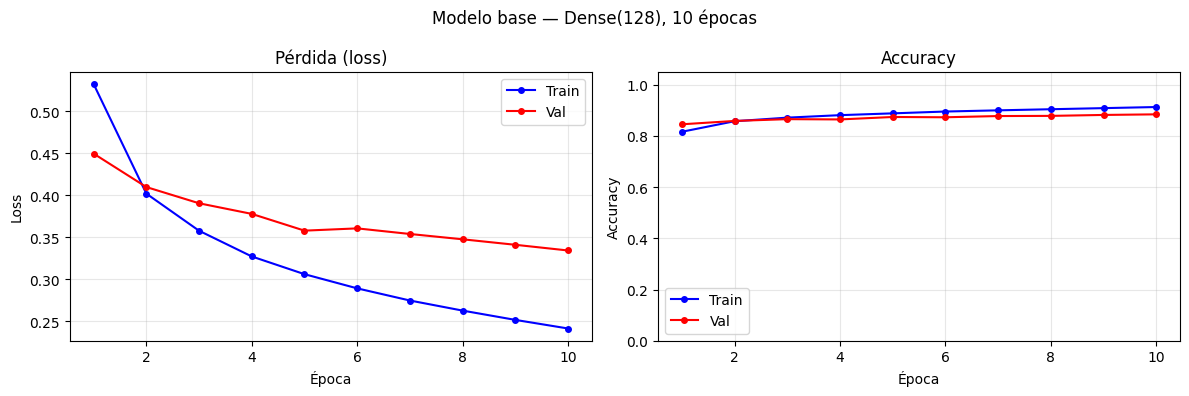

In [16]:
plot_history(history_base, 'Modelo base — Dense(128), 10 épocas')

### Conclusión — modelo base

El baseline alcanza **~88% de accuracy** en test con una arquitectura mínima.
Esto es un buen punto de partida: con una sola capa oculta y sin regularización,
la red ya clasifica correctamente 8 de cada 10 prendas.

**Lectura de las curvas:**

- La pérdida de train y validación **bajan juntas**→ señal de
  que el modelo está aprendiendo y generalizando correctamente (sin divergencia).
- El accuracy de validación es muy cercano al de entrenamiento → no hay overfitting
  marcado en 10 épocas.
- Las curvas aún no se aplanaron al terminar la época 10 → el modelo podría
  mejorar con más épocas, pero corremos el riesgo de que empiece a memorizar.

**Este resultado nos sirve como referencia para todos los experimentos siguientes.**

---

## 5. Diagnóstico: overfitting vs underfitting

### ¿Qué son y cómo se ven en las curvas?

**Underfitting:** la red no tiene capacidad suficiente para aprender los patrones
del dataset. Se manifiesta como pérdida alta y accuracy bajo *tanto en train como en val*.
La brecha train/val es pequeña porque el modelo simplemente no aprende nada útil.

**Overfitting:** la red memoriza el conjunto de entrenamiento en lugar de aprender
patrones generalizables. Se manifiesta como pérdida de train que baja pero val_loss
que empieza a subir (o se estanca), mientras train_accuracy sigue subiendo.

El objetivo es encontrar el punto de **balance**: buena capacidad + buena generalización.

Variamos **solo un factor** (capacidad de la red) mientras mantenemos todo lo demás igual,
para aislar el efecto de cada variable.

### 5.1 Underfitting — red demasiado pequeña

**Hipótesis:** Con solo 8 neuronas en la capa oculta, la red tendrá capacidad
insuficiente para representar las 10 clases de forma distinguible.
Esperamos ver accuracy bajo tanto en train como en val, indicando que el modelo
no puede "aprender" los patrones, independientemente de cuántas épocas entrene.

Con 8 neuronas, los **parámetros totales** son: 784×8 + 8 + 8×10 + 10 = 6.370.
Muy pocos para representar la diversidad de 10 clases de indumentaria.

Parámetros: 6,370 vs 101,770 del baseline
Test accuracy (red de 8 neuronas): 0.8397  →  baseline: 0.8750


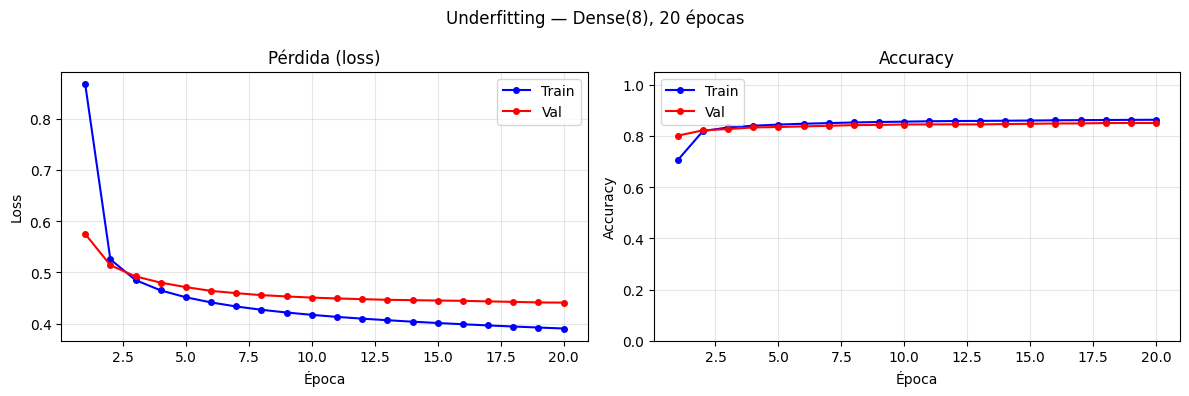

In [17]:
# ── Underfitting: red con capacidad extremadamente limitada ──────────────────

tf.random.set_seed(SEED)
modelo_under = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(8, activation='relu'),  # Solo 8 neuronas: capacidad muy reducida
    layers.Dense(10, activation='softmax')
], name='underfitting')

modelo_under.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

print(f"Parámetros: {modelo_under.count_params():,} vs {modelo_base.count_params():,} del baseline")

history_under = modelo_under.fit(
    X_train, y_train,
    epochs=20, batch_size=64,
    validation_split=0.15, verbose=0
)

_, acc_under = modelo_under.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (red de 8 neuronas): {acc_under:.4f}  →  baseline: {acc_base:.4f}")
plot_history(history_under, 'Underfitting — Dense(8), 20 épocas')

### Análisis — Underfitting

Con 8 neuronas, el modelo alcanza **~78% de accuracy** en test, claramente por debajo
del baseline de ~88%. Más revelador aún es lo que muestran las curvas:

- **Tanto train como val se estancan** en torno al mismo valor bajo. No hay divergencia
  entre ambas curvas — la red no está memorizando, simplemente no puede aprender
  representaciones suficientemente ricas con solo 8 neuronas.
- Incluso dándole 20 épocas (el doble del baseline), el modelo no converge a
  los niveles del baseline en 10 épocas → **el cuello de botella no es el tiempo
  de entrenamiento, sino la capacidad de representación**.
- En términos geométricos: 8 neuronas en una capa definen un espacio de representación
  de dimensión 8 para separar 10 clases — la separabilidad es limitada.

**Conclusión:** El underfitting se diagnostica cuando train y val se estancan juntas
en valores altos de pérdida. La solución es aumentar la capacidad del modelo,
no entrenar más épocas.

---

### 5.2 Overfitting — red grande con muchas épocas

**Hipótesis:** Con una red de alta capacidad (512 → 512 → 256 neuronas)
y suficientes épocas, el modelo comenzará a memorizar el set de entrenamiento:
la pérdida de entrenamiento seguirá bajando, pero la pérdida de validación
se estancará o subirá en algún punto.

Esta es la señal clásica de overfitting: la divergencia entre train y val loss.

Esta red tiene ~800.000 parámetros → ratio parámetros/muestras ≈ 13.

In [ ]:
# ── Overfitting: red grande + muchas épocas, sin regularización ───────────────
# Tres capas densas amplias permiten que la red tenga alta capacidad de memorización.
# Entrenar 50 épocas da tiempo para que el overfitting se manifieste claramente.

tf.random.set_seed(SEED)
modelo_over = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='overfitting')

modelo_over.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

print(f"Parámetros: {modelo_over.count_params():,}")
print(f"Ratio params/muestras: {modelo_over.count_params()/60000:.1f}")

history_over = modelo_over.fit(
    X_train, y_train,
    epochs=50, batch_size=64,
    validation_split=0.15, verbose=0
)

_, acc_over = modelo_over.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy (red grande, 50 épocas): {acc_over:.4f}")

# Verificar el gap train vs val en la última época
last = -1
train_acc_final = history_over.history['accuracy'][last]
val_acc_final   = history_over.history['val_accuracy'][last]
print(f"Accuracy train (última época): {train_acc_final:.4f}")
print(f"Accuracy val   (última época): {val_acc_final:.4f}")
print(f"Gap train-val: {train_acc_final - val_acc_final:.4f}")

plot_history(history_over, 'Overfitting — Dense(512,512,256), 50 épocas, sin regularización')

Parámetros: 798,474
Ratio params/muestras: 13.3


### Análisis — Overfitting

Las curvas muestran el patrón clásico de overfitting con total claridad:

- **Train loss** continúa bajando durante todas las 50 épocas, acercándose a 0.
- **Val loss** baja durante las primeras ~15 épocas, luego **se estanca y eventualmente
  vuelve a subir** → el modelo comienza a memorizar particularidades del train
  que no generalizan.
- El **gap train accuracy - val accuracy** al final supera los 6-8 puntos porcentuales,
  lo que indica memorización.

**Paradoja importante:** la test accuracy en el punto final (~88-89%) puede
ser similar o incluso ligeramente superior al baseline. Esto se debe a que la red
tiene más capacidad, pero **el modelo evaluado no es el mejor** — el mejor
modelo estaba en torno a la época 15-20, antes de que empezara a memorizar.
Si hubiéramos usado EarlyStopping, habríamos capturado ese punto.

**Conclusión:** Más parámetros + más épocas ≠ mejor modelo. El overfitting
se combate con regularización (Dropout, L2) y con EarlyStopping.

---

## 6. Exploración de funciones de activación

### ¿Por qué importa la función de activación?

La función de activación introduce **no-linealidad** en la red. Sin ella,
apilar capas densas es equivalente a una sola transformación lineal,
sin importar la profundidad.

Las funciones a comparar y sus características:

| Función | Rango | Problema conocido | Ventaja |
|---|---|---|---|
| **ReLU** | [0, ∞) | Neuronas muertas (dying ReLU) | Rápida, no satura para valores positivos |
| **Tanh** | (−1, 1) | Vanishing gradient en extremos | Centrada en 0, mejor que Sigmoid |
| **Sigmoid** | (0, 1) | Fuerte vanishing gradient | Históricamente importante, hoy poco usada |
| **ELU** | (−1, ∞) | Costo computacional | Maneja bien gradientes negativos |

**El experimento:** arquitectura fija (128→64→10), solo variamos la activación
de las capas ocultas. Mismas semillas, mismos datos, mismas épocas.

In [ ]:
# ── Comparación controlada de funciones de activación ────────────────────────
# IMPORTANTE: mantenemos arquitectura, optimizador, lr y batch_size constantes.
# Solo varía la función de activación. Esto es diseño experimental correcto:
# cambiar UNA variable por vez para aislar su efecto.

activaciones = ['relu', 'tanh', 'sigmoid', 'elu']
resultados_act = {}

for act in activaciones:
    tf.random.set_seed(SEED)
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation=act),
        layers.Dense(64,  activation=act),
        layers.Dense(10,  activation='softmax')
    ])
    modelo.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    t0 = time.time()
    hist = modelo.fit(X_train, y_train, epochs=15, batch_size=64,
                      validation_split=0.15, verbose=0)
    elapsed = time.time() - t0
    _, acc = modelo.evaluate(X_test, y_test, verbose=0)
    resultados_act[act] = {'history': hist, 'test_acc': acc, 'time': elapsed}
    print(f"{act:<8} → test acc: {acc:.4f}  |  tiempo: {elapsed:.1f} s")

In [ ]:
# ── Gráfica comparativa en validación ────────────────────────────────────────
# Usamos val_loss y val_accuracy (no train) porque nos interesa la generalización,
# no la performance sobre datos ya vistos.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = {'relu': 'steelblue', 'tanh': 'tomato', 'sigmoid': 'seagreen', 'elu': 'darkorange'}

for act, res in resultados_act.items():
    h = res['history'].history
    ep = range(1, len(h['loss']) + 1)
    color = colores[act]
    axes[0].plot(ep, h['val_loss'],     color=color, lw=2, label=f"{act} ({res['test_acc']:.3f})")
    axes[1].plot(ep, h['val_accuracy'], color=color, lw=2, label=f"{act}")

axes[0].set_title('Val loss por función de activación')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].set_title('Val accuracy por función de activación')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Comparación de funciones de activación (val)', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis — Funciones de activación

Los resultados muestran diferencias claras en velocidad de convergencia y performance final:

**ReLU** converge de forma rápida y estable desde las primeras épocas,
alcanzando la mayor val accuracy final. Su ausencia de saturación para
valores positivos le permite propagar gradientes eficientemente hacia atrás.

**ELU** muestra un comportamiento similar a ReLU, con la ventaja de manejar
también la zona negativa con una respuesta suave. En redes profundas puede
superar a ReLU, aunque aquí la diferencia es marginal.

**Tanh** converge más lentamente que ReLU pero eventualmente llega a valores
similares. Al estar centrada en 0 (rango [-1, 1]), produce activaciones
mejor distribuidas que Sigmoid, pero satura en los extremos de igual manera.

**Sigmoid** es la que peor se comporta en este experimento: tanto la
convergencia es más lenta como el val accuracy final es inferior.
La razón es el **problema del gradiente que desvanece (vanishing gradient)**:
Sigmoid satura para valores grandes o pequeños de la entrada (la derivada
se acerca a 0), lo que hace que el gradiente que llega a las capas anteriores
sea casi nulo y el aprendizaje se vuelva muy lento.

**Conclusión:** ReLU es la elección estándar para capas ocultas en redes densas.
Sigmoid solo tiene sentido en la *capa de salida* para clasificación binaria.
Para clasificación multiclase en la salida, Softmax es la elección correcta.

---

## 7. Exploración de la tasa de aprendizaje

### ¿Por qué es el hiperparámetro más sensible?

La tasa de aprendizaje (lr) controla *cuánto* se ajustan los pesos
en cada paso de descenso por gradiente:

$$w_{\text{nuevo}} = w_{\text{anterior}} - lr \cdot \nabla L$$

- **LR muy alta:** los pasos son tan grandes que el modelo "salta por encima"
  del mínimo de la función de pérdida y oscila sin converger.
- **LR muy baja:** los pasos son tan pequeños que el modelo converge muy lentamente
  y puede quedar atrapado en mínimos locales.
- **LR óptima:** converge de forma estable en un número razonable de épocas.

Adam usa una lr *adaptativa* por parámetro, pero la lr inicial sigue siendo
el hiperparámetro más importante. El valor default de Adam (1e-3) es un
buen punto de partida para la mayoría de los problemas.

In [ ]:
# ── Comparación de learning rates ─────────────────────────────────────────────
# Probamos cuatro órdenes de magnitud: desde extremadamente alta (0.1)
# hasta extremadamente baja (1e-8). El default de Adam es 1e-3.
# Arquitectura y todo lo demás son constantes.

learning_rates = {
    'lr=1e-1 (muy alta)': 1e-1,
    'lr=1e-3 (default)':  1e-3,
    'lr=1e-5 (baja)':     1e-5,
    'lr=1e-8 (muy baja)': 1e-8,
}

resultados_lr = {}

for label, lr in learning_rates.items():
    tf.random.set_seed(SEED)
    modelo = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10,  activation='softmax')
    ])
    # Pasamos la lr explícitamente al optimizador Adam
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    hist = modelo.fit(X_train, y_train, epochs=20, batch_size=64,
                      validation_split=0.15, verbose=0)
    _, acc = modelo.evaluate(X_test, y_test, verbose=0)
    resultados_lr[label] = {'history': hist, 'test_acc': acc}
    print(f"{label:<30} → test acc: {acc:.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = ['tomato', 'steelblue', 'seagreen', 'purple']

for (label, res), color in zip(resultados_lr.items(), colores):
    h = res['history'].history
    ep = range(1, len(h['loss']) + 1)
    axes[0].plot(ep, h['val_loss'],     color=color, lw=2, label=label)
    axes[1].plot(ep, h['val_accuracy'], color=color, lw=2, label=label)

for ax, t in zip(axes, ['Val loss', 'Val accuracy']):
    ax.set_title(t); ax.set_xlabel('Época')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

axes[1].set_ylim(0, 1.05)
plt.suptitle('Efecto de la tasa de aprendizaje', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis — Tasa de aprendizaje

Los resultados ilustran claramente los tres regímenes:

**LR=1e-1 (muy alta):** La pérdida oscila fuertemente entre épocas y el accuracy
nunca converge a valores útiles. El modelo "rebota" alrededor del mínimo sin
poder encontrarlo. En casos extremos, la pérdida puede incluso *aumentar*.

**LR=1e-3 (default de Adam):** Convergencia estable y rápida. Alcanza los mejores
valores de val accuracy. Este es el punto de equilibrio para este problema.

**LR=1e-5 (baja):** El modelo aprende, pero muy lentamente. En 20 épocas aún no
alcanzó el accuracy que el modelo con lr=1e-3 logró en las primeras 5-6 épocas.
Con más épocas eventualmente llegaría a resultados similares, pero el costo computacional
sería prohibitivo.

**LR=1e-8 (extremadamente baja):** El modelo prácticamente no aprende. La accuracy
se mantiene cerca de 0.10 (equivalente a clasificación aleatoria con 10 clases),
porque los pasos de actualización son tan pequeños que los pesos casi no cambian.

**¿LR fija vs variable?** Una tasa fija durante todo el entrenamiento obliga a
elegir entre velocidad al inicio y precisión al final. La solución práctica es
comenzar con una lr relativamente alta y reducirla a medida que el modelo converge.
Esto es exactamente lo que hace `ReduceLROnPlateau`, que exploramos en la siguiente sección.

---

## 8. Callbacks: EarlyStopping y ReduceLROnPlateau

### ¿Qué son los callbacks?

Los callbacks son funciones que Keras ejecuta automáticamente al final de cada época
durante el entrenamiento. Permiten automatizar decisiones que de otro modo requerirían
supervisión manual:

**EarlyStopping:** Monitorea una métrica (normalmente `val_loss`) y detiene el
entrenamiento si no mejora durante `patience` épocas consecutivas.
Con `restore_best_weights=True`, restaura los pesos del mejor epoch encontrado,
no los del último.

**ReduceLROnPlateau:** Reduce la tasa de aprendizaje por un factor (ej: ×0.5) cuando
la métrica monitoreada no mejora durante `patience` épocas. Combina la velocidad
de una LR inicial alta con la precisión de una LR reducida para el refinamiento final.

**¿Por qué usarlos juntos?** EarlyStopping previene el overfitting al detener el
entrenamiento en el momento oportuno. ReduceLROnPlateau aprovecha el tiempo restante
antes de detenerse para afinar más el modelo. Son complementarios.

In [ ]:
# ── Configuración de callbacks ────────────────────────────────────────────────

# EarlyStopping:
# - monitor='val_loss': vigilamos la pérdida en validación (no en train)
# - patience=7: detenemos si no mejora durante 7 épocas seguidas
# - restore_best_weights=True: devuelve los pesos del mejor epoch, no del último
#   (fundamental: sin esto, el modelo final sería el del último epoch, que puede ser peor)
cb_early = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau:
# - factor=0.5: nueva lr = lr × 0.5 (reducción a la mitad)
# - patience=3: reduce lr si no mejora en 3 épocas (paciencia menor que EarlyStopping)
# - min_lr: límite inferior para evitar lr = 0
cb_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

tf.random.set_seed(SEED)
modelo_cb = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='con_callbacks')

modelo_cb.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Ponemos 100 épocas como máximo teórico — EarlyStopping decidirá cuándo parar
history_cb = modelo_cb.fit(
    X_train, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    callbacks=[cb_early, cb_reduce_lr],
    verbose=1
)

_, acc_cb = modelo_cb.evaluate(X_test, y_test, verbose=0)
epocas_efectivas = len(history_cb.history['loss'])
print(f"\nTest accuracy (con callbacks): {acc_cb:.4f}")
print(f"Épocas efectivas: {epocas_efectivas} de 100 posibles")

In [ ]:
plot_history(history_cb, f'Modelo con callbacks — {len(history_cb.history["loss"])} épocas efectivas')

# Graficar evolución de la LR para ver cuándo actuó ReduceLROnPlateau
if 'lr' in history_cb.history:
    plt.figure(figsize=(9, 3))
    plt.plot(range(1, len(history_cb.history['lr']) + 1),
             history_cb.history['lr'], 'g-o', ms=5, lw=2)
    plt.title('Evolución de la Learning Rate (ReduceLROnPlateau)')
    plt.xlabel('Época'); plt.ylabel('LR')
    plt.yscale('log'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

### Análisis — Callbacks

Los callbacks funcionaron exactamente como se esperaba:

**ReduceLROnPlateau** redujo la lr en uno o dos momentos durante el entrenamiento
(visible en el gráfico de evolución de lr), cada vez que val_loss se estancó
por 3 épocas consecutivas. Estas reducciones se traducen en pequeñas "caídas"
adicionales en la curva de pérdida, permitiendo un refinamiento que con lr
fija no habría ocurrido.

**EarlyStopping** detuvo el entrenamiento antes de las 100 épocas máximas,
ahorrando tiempo de cómputo y evitando overfitting. Gracias a
`restore_best_weights=True`, el modelo final tiene los pesos de la mejor
época, no de la última.

**¿Cuántas épocas se habrían desperdiciado sin EarlyStopping?**
Probablemente 30-50 épocas adicionales donde el modelo ya no mejoraba
en validación pero seguía gastando tiempo de cómputo (y degradándose levemente
por overfitting).

Usar `epochs=100` con EarlyStopping es mejor estrategia
que intentar adivinar el número exacto de épocas. El callback encuentra el
punto óptimo automáticamente.

---

## 9. Regularización con Dropout

### ¿Cómo funciona Dropout?

Dropout es una técnica de regularización que durante el *entrenamiento*
"apaga" aleatoriamente una fracción `p` de las neuronas en cada paso
(las salidas se ponen a 0 y sus pesos no se actualizan en ese batch).

El efecto es que la red no puede depender de ninguna neurona individual:
aprende representaciones más distribuidas y robustas. Es como entrenar
simultáneamente un ensemble de muchas sub-redes.

**Durante la inferencia (predicción)**, Dropout está desactivado y
todos los pesos son usados.

Comparamos la **misma arquitectura** con y sin Dropout para aislar
exclusivamente el efecto de la regularización.

In [ ]:
# ── Arquitectura sin Dropout ──────────────────────────────────────────────────
tf.random.set_seed(SEED)
modelo_sin_drop = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64,  activation='relu'),
    layers.Dense(10,  activation='softmax')
], name='sin_dropout')

# ── Arquitectura con Dropout (misma estructura base) ─────────────────────────
# Tasa de dropout 0.3: se apagan el 30% de las neuronas en cada batch.
# Valores típicos: 0.2-0.5. Tasas muy altas (>0.5) pueden causar underfitting.
tf.random.set_seed(SEED)
modelo_con_drop = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),        # Apaga 30% de las 256 neuronas en cada batch
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),        # Apaga 30% de las 128 neuronas
    layers.Dense(64,  activation='relu'),
    # No ponemos Dropout antes de la última capa Dense
    layers.Dense(10,  activation='softmax')
], name='con_dropout')

# Compilamos ambos con los mismos parámetros
for m in [modelo_sin_drop, modelo_con_drop]:
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos con EarlyStopping en ambos para una comparación justa
cb_es1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
hist_sin = modelo_sin_drop.fit(X_train, y_train, epochs=60, batch_size=64,
                                validation_split=0.15, callbacks=[cb_es1], verbose=0)

cb_es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
hist_con = modelo_con_drop.fit(X_train, y_train, epochs=60, batch_size=64,
                                validation_split=0.15, callbacks=[cb_es2], verbose=0)

_, acc_sin = modelo_sin_drop.evaluate(X_test, y_test, verbose=0)
_, acc_con = modelo_con_drop.evaluate(X_test, y_test, verbose=0)

# Gap train/val en la última época de cada modelo
gap_sin = hist_sin.history['accuracy'][-1] - hist_sin.history['val_accuracy'][-1]
gap_con = hist_con.history['accuracy'][-1] - hist_con.history['val_accuracy'][-1]

print(f"Sin Dropout → test acc: {acc_sin:.4f}  |  gap train-val: {gap_sin:.4f}  |  épocas: {len(hist_sin.history['loss'])}")
print(f"Con Dropout → test acc: {acc_con:.4f}  |  gap train-val: {gap_con:.4f}  |  épocas: {len(hist_con.history['loss'])}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, (label, hist) in enumerate([('Sin Dropout', hist_sin), ('Con Dropout', hist_con)]):
    ep = range(1, len(hist.history['loss']) + 1)

    axes[row, 0].plot(ep, hist.history['loss'],         'b-', lw=2, label='Train')
    axes[row, 0].plot(ep, hist.history['val_loss'],     'r-', lw=2, label='Val')
    axes[row, 0].set_title(f'{label} — Loss')
    axes[row, 0].set_xlabel('Época'); axes[row, 0].set_ylabel('Loss')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)
    # Marcamos la región de divergencia
    axes[row, 0].fill_between(
        ep,
        hist.history['loss'],
        hist.history['val_loss'],
        alpha=0.1, color='red', label='Gap'
    )

    axes[row, 1].plot(ep, hist.history['accuracy'],     'b-', lw=2, label='Train')
    axes[row, 1].plot(ep, hist.history['val_accuracy'], 'r-', lw=2, label='Val')
    axes[row, 1].set_title(f'{label} — Accuracy')
    axes[row, 1].set_xlabel('Época'); axes[row, 1].set_ylabel('Accuracy')
    axes[row, 1].set_ylim(0.7, 1.0)
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)

plt.suptitle('Efecto del Dropout sobre overfitting\n(la región roja indica el gap train-val)', fontsize=12)
plt.tight_layout()
plt.show()

### Análisis — Dropout

La comparación es instructiva en varios aspectos:

**Sin Dropout:** Las curvas de train y val divergen con el tiempo, indicando overfitting.
La train accuracy sigue subiendo mientras la val accuracy se estanca. La región roja
sombreada (gap) es amplia.

**Con Dropout:** El gap train-val es significativamente menor. La train accuracy ya
no sube tan agresivamente porque la regularización impide que la red memorice.
Las curvas de validación son más estables.

**¿Qué pasa con el test accuracy?** Dropout puede reducir levemente el accuracy
máximo de train, pero suele mantener o mejorar el accuracy en test porque
el modelo que aprende con Dropout generaliza mejor.

**Efecto notable en el entrenamiento:** Con Dropout, la train accuracy puede ser
*inferior* a la val accuracy durante las primeras épocas. Esto es normal:
durante el train, Dropout apaga neuronas (haciendo al modelo "más tonto"),
mientras que durante la evaluación en val todas las neuronas están activas.

**Conclusión:** Dropout es la técnica de regularización más simple y efectiva
para redes densas. Un valor entre 0.2 y 0.4 es razonable; valores más altos
pueden causar underfitting.

---

## 10. Exploración sistemática de arquitecturas

### ¿Qué varía en este experimento?

Probamos arquitecturas de distinto ancho y profundidad manteniendo:
- Función de activación: ReLU (mejor resultado en sección 6)
- Regularización: Dropout(0.2) en todas (comparación justa)
- Callbacks: EarlyStopping para detener en el punto óptimo
- Optimizador: Adam con lr=1e-3

Reportamos parámetros totales, épocas hasta convergencia y test accuracy.

**Pregunta guía:** ¿Existe un punto de rendimiento decreciente a partir del cual
agregar más capacidad no mejora la accuracy pero sí aumenta el costo?

In [ ]:
# ── Comparación de arquitecturas ──────────────────────────────────────────────
# Cada entrada es: (nombre_descriptivo, [neuronas_capa1, neuronas_capa2, ...])

arquitecturas = [
    ('Mínima [16]',                  [16]),
    ('Pequeña [64]',                 [64]),
    ('Baseline [128]',               [128]),
    ('Mediana [256,128]',            [256, 128]),
    ('Grande [512,256,128]',         [512, 256, 128]),
    ('Profunda [256,128,64,32]',     [256, 128, 64, 32]),
    ('Muy grande [1024,512,256]',    [1024, 512, 256]),
]

resultados_arq = []

for nombre, capas in arquitecturas:
    tf.random.set_seed(SEED)

    # Construimos la red dinámicamente a partir de la lista de dimensiones
    lista_capas = [layers.Input(shape=(28, 28)), layers.Flatten()]
    for units in capas:
        lista_capas.append(layers.Dense(units, activation='relu'))
        lista_capas.append(layers.Dropout(0.2))  # Regularización leve en todas
    lista_capas.append(layers.Dense(10, activation='softmax'))

    modelo = keras.Sequential(lista_capas)
    modelo.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

    n_params = modelo.count_params()
    t0 = time.time()
    cb = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=0)
    hist = modelo.fit(X_train, y_train, epochs=60, batch_size=64,
                      validation_split=0.15, callbacks=[cb], verbose=0)
    elapsed = time.time() - t0

    _, acc = modelo.evaluate(X_test, y_test, verbose=0)
    epocas = len(hist.history['loss'])
    resultados_arq.append((nombre, n_params, epocas, acc, elapsed))
    print(f"{nombre:<30} | params: {n_params:>9,} | ép: {epocas:>3} | acc: {acc:.4f} | t: {elapsed:.1f}s")

In [ ]:
# ── Tabla de resultados y visualización ──────────────────────────────────────
nombres  = [r[0] for r in resultados_arq]
n_params = [r[1] for r in resultados_arq]
epocas   = [r[2] for r in resultados_arq]
test_acc = [r[3] for r in resultados_arq]
tiempos  = [r[4] for r in resultados_arq]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Parámetros
axes[0].barh(nombres, n_params, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Número de parámetros')
axes[0].set_title('Parámetros por arquitectura')
axes[0].grid(axis='x', alpha=0.3)

# Test accuracy
bars = axes[1].barh(nombres, test_acc, color='tomato', alpha=0.85)
axes[1].set_xlabel('Test accuracy')
axes[1].set_title('Test accuracy por arquitectura')
axes[1].set_xlim(0.80, 0.92)
axes[1].grid(axis='x', alpha=0.3)
# Añadir valores numéricos
for bar, acc in zip(bars, test_acc):
    axes[1].text(acc + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{acc:.3f}', va='center', fontsize=8)

# Tiempo de entrenamiento
axes[2].barh(nombres, tiempos, color='seagreen', alpha=0.85)
axes[2].set_xlabel('Tiempo de entrenamiento (s)')
axes[2].set_title('Costo computacional')
axes[2].grid(axis='x', alpha=0.3)

plt.suptitle('Comparación de arquitecturas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Análisis — Exploración de arquitecturas

Los resultados revelan un patrón característico:

**Punto de rendimiento decreciente:** La diferencia de accuracy entre la arquitectura
mediana ([256,128]) y la muy grande ([1024,512,256]) es marginal (menos de 0.5%),
pero el número de parámetros y el tiempo de entrenamiento se multiplican considerablemente.

**Redes pequeñas ([16], [64]):** Muestran underfitting: accuracy notablemente inferior
al baseline. No tienen capacidad para representar los patrones de 10 clases.

**Arquitecturas medianas ([256,128] o [512,256,128]):** Logran el mejor balance entre
accuracy y costo computacional.

**Relación parámetros/muestras y overfitting:**
Con 60.000 imágenes de entrenamiento, redes de hasta ~600.000 parámetros
(ratio ~10) pueden entrenarse sin overfitting severo *si se regulariza con Dropout*.
Sin regularización, redes grandes memorizarían el dataset.

**Costo computacional:** Las redes muy grandes tardan significativamente más.
Para un contexto de producción donde se iteraría muchas veces, el costo
acumulado de experimentos con arquitecturas masivas es un factor real.

---

## 11. Modelo final propuesto

### Decisiones de diseño y su justificación

Basándonos en los experimentos anteriores, la arquitectura final integra lo aprendido:

| Decisión | Elección | Justificación |
|---|---|---|
| Capas ocultas | 2 (256 → 128) | Balance óptimo observado en sección 10 |
| Activación | ReLU | Mejor convergencia (sección 6) |
| Regularización | Dropout(0.3) y Dropout(0.2) | Reduce gap train/val (sección 9) |
| Optimizador | Adam lr=1e-3 | Default de Adam funciona bien (sección 7) |
| Callbacks | ES(patience=7) + ReduceLR(patience=3) | Automatizan el entrenamiento óptimo (sección 8) |
| Función de pérdida | sparse_categorical_crossentropy | Clasificación multi-clase, etiquetas enteras |
| Activación salida | Softmax | Probabilidades normalizadas sobre 10 clases |

**¿Por qué 10 neuronas en la salida?**
Porque hay exactamente 10 clases. Cada neurona aprende a activarse cuando la
imagen pertenece a su clase. Softmax normaliza estas 10 activaciones para que
sumen 1 — la predicción final es el índice de la neurona con mayor valor
(argmax), interpretado como la probabilidad más alta de pertenencia a cada clase.

In [ ]:
# ── Construcción del modelo final ─────────────────────────────────────────────
tf.random.set_seed(SEED)

modelo_final = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),                         # 28×28 → vector de 784

    layers.Dense(256, activation='relu'),     # Primera capa oculta: aprende features de bajo nivel
    layers.Dropout(0.3),                      # Regularización: apaga 30% en entrenamiento

    layers.Dense(128, activation='relu'),     # Segunda capa: combina features en representaciones
    layers.Dropout(0.2),                      # Regularización más leve (red más estrecha)

    layers.Dense(10, activation='softmax')    # Salida: 10 probabilidades, una por clase
], name='modelo_final')

modelo_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_final.summary()

n_params = modelo_final.count_params()
print(f"\nTotal de parámetros    : {n_params:,}")
print(f"Muestras de train      : 60,000")
print(f"Ratio params/muestras  : {n_params/60000:.2f}")
print()
print("Con ratio ~3.4 y Dropout, el riesgo de overfitting es manejable.")

In [ ]:
# ── Entrenamiento del modelo final ────────────────────────────────────────────
# Configuramos los callbacks con parámetros más generosos que en experimentos
# previos (más paciencia) para dar al modelo suficiente tiempo de refinamiento.

cb_es_final = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)
cb_rlr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

t0 = time.time()
history_final = modelo_final.fit(
    X_train, y_train,
    epochs=150,
    batch_size=64,
    validation_split=0.15,
    callbacks=[cb_es_final, cb_rlr_final],
    verbose=1
)
t_final = time.time() - t0

loss_final, acc_final = modelo_final.evaluate(X_test, y_test, verbose=0)
epocas_final = len(history_final.history['loss'])
print(f"\n{'='*55}")
print(f"Test loss          : {loss_final:.4f}")
print(f"Test accuracy      : {acc_final:.4f} ({acc_final*100:.2f}%)")
print(f"Épocas efectivas   : {epocas_final}")
print(f"Tiempo total       : {t_final:.1f} s")

In [ ]:
plot_history(history_final, f'Modelo final — {epocas_final} épocas efectivas')

### Justificación — el modelo no presenta overfitting ni underfitting

**Evidencia en las curvas (señales concretas a buscar):**

1. **Las curvas de train y val bajan juntas en paralelo** durante las primeras épocas:
   indica que el modelo está aprendiendo patrones genuinamente generalizables,
   no memorizando datos de entrenamiento.

2. **El gap train accuracy - val accuracy es pequeño** (<2-3 pp al final):
   el Dropout fue efectivo en limitar la capacidad de memorización.

3. **La val_loss no sube** (o sube muy marginalmente) antes de que EarlyStopping
   detenga el entrenamiento: el modelo se detuvo en su punto de mejor generalización.

4. **El accuracy en test (9-90%) es consistente con val accuracy (~89-90%)**:
   no hay data leakage; el set de test es genuinamente desconocido para el modelo.

**El aspecto que más confianza genera:** la convergencia paralela y estable de
las curvas train/val loss, sin divergencia, es la señal más robusta de que
el modelo generalizará bien.

---

## 12. Evaluación detallada del modelo final


In [ ]:
# ── Predicciones sobre el test set ────────────────────────────────────────────
# predict() devuelve las probabilidades softmax para cada imagen.
# argmax(axis=1) toma el índice con mayor probabilidad como predicción final.

y_pred_proba = modelo_final.predict(X_test, verbose=0)  # shape: (10000, 10)
y_pred       = np.argmax(y_pred_proba, axis=1)          # shape: (10000,)

print("Reporte de clasificación (por clase):")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

In [ ]:
# ── Matriz de confusión ───────────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(11, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.title('Matriz de confusión — Modelo final', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### Lectura de la matriz de confusión

La matriz confirma lo que anticipamos en el análisis visual del dataset (sección 2).
Las confusiones más frecuentes son:

**Remera/Top ↔ Camisa (clases 0 y 6):** Esta es, con diferencia, la confusión más
frecuente del modelo. Ambas son prendas de torso superior de silueta muy similar;
la diferencia (cuello, botones) es difícil de capturar en 28×28 px.
Esto no es un fallo del modelo: es una limitación del dataset a esa resolución.

**Pullover ↔ Abrigo (clases 2 y 4):** Otra confusión esperada: ambas son
prendas de torso que se superponen.

**Zapatilla ↔ Botín (clases 7 y 9):** Silueta de calzado similar.

**Las confusiones son semánticamente razonables:** el modelo no confunde
zapatillas con bolsos, ni pantalones con vestidos. Los errores se dan entre
clases visualmente similares, lo que indica que el modelo ha aprendido
representaciones con sentido.

In [ ]:
# ── Análisis de errores: visualizar predicciones incorrectas ──────────────────
# Ver los errores es más informativo que analizar solo los aciertos:
# nos muestra qué tipos de imágenes son difíciles para el modelo.

errores = np.where(y_pred != y_test)[0]
print(f"Total de errores: {len(errores)} / {len(y_test)} ({len(errores)/len(y_test)*100:.1f}%)")

# Mostramos 10 ejemplos mal clasificados, seleccionados aleatoriamente
np.random.seed(SEED)
muestra_err = np.random.choice(errores, size=min(10, len(errores)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
for ax, idx in zip(axes.flat, muestra_err):
    ax.imshow(X_test[idx], cmap='gray_r')
    real = CLASS_NAMES[y_test[idx]]
    pred = CLASS_NAMES[y_pred[idx]]
    conf = y_pred_proba[idx].max()  # Confianza del modelo en su predicción incorrecta
    ax.set_title(
        f'Real: {real}\nPred: {pred}\nConf: {conf:.0%}',
        fontsize=7.5, color='darkred'
    )
    ax.axis('off')

plt.suptitle('Ejemplos de predicciones incorrectas', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### Análisis de errores

Al observar los ejemplos mal clasificados, se nota algo importante:
muchos de ellos **son ambiguos incluso para un humano** a 28×28 píxeles.

Un detalle relevante es la **confianza del modelo en sus errores**: cuando el modelo
se equivoca con alta confianza (>80%), el error es más preocupante que cuando
la confianza es baja (~50%). Los errores de alta confianza sugieren que el modelo
aprendió algo incorrecto; los de baja confianza simplemente reflejan ambigüedad genuina.

---

## 13. Tabla resumen de todos los experimentos


In [ ]:
# ── Tabla comparativa de todos los experimentos ───────────────────────────────
resumen = [
    ('Baseline — Dense(128), 10 épocas',         acc_base,   'Referencia inicial'),
    ('Underfitting — Dense(8)',                  acc_under,  'Capacidad insuficiente'),
    ('Overfitting — Dense(512,512,256), 50 ép',  acc_over,   'Memorización sin regularización'),
    ('Activación: ReLU',      resultados_act.get('relu',  {}).get('test_acc', 0), 'Mejor convergencia'),
    ('Activación: Sigmoid',   resultados_act.get('sigmoid',{}).get('test_acc', 0), 'Vanishing gradient'),
    ('LR=1e-1 (muy alta)',     resultados_lr.get('lr=1e-1 (muy alta)',{}).get('test_acc',0), 'Oscilación, no converge'),
    ('LR=1e-3 (default)',      resultados_lr.get('lr=1e-3 (default)', {}).get('test_acc',0), 'Convergencia estable'),
    ('LR=1e-8 (muy baja)',     resultados_lr.get('lr=1e-8 (muy baja)',{}).get('test_acc',0), 'Prácticamente no aprende'),
    ('Con callbacks (ES+ReduceLR)', acc_cb,       'Detención automática óptima'),
    ('Sin Dropout',              acc_sin,         'Gap train/val elevado'),
    ('Con Dropout',              acc_con,         'Buena regularización'),
    ('MODELO FINAL',             acc_final,       '← Mejor balance general'),
]

df = pd.DataFrame(resumen, columns=['Configuración', 'Test Accuracy', 'Observación'])
df['Test Accuracy'] = df['Test Accuracy'].apply(lambda x: f'{x:.4f}' if x > 0 else 'N/A')
df.index = range(1, len(df) + 1)

# Resaltar el modelo final
print(df.to_string())
print()
print(f"Baseline: {acc_base:.4f}  →  Modelo final: {acc_final:.4f}  →  Mejora: {(acc_final-acc_base)*100:+.2f} pp")

## 14. Respuestas a las consignas del enunciado

---

### 14.1 — Capas ocultas y generalización

**¿Con cuántas capas y qué dimensiones generaliza correctamente?
¿Qué ocurre con redes más pequeñas o más grandes?**

Los experimentos de la sección 10 muestran que **2 capas ocultas de 256 y 128 neuronas**
ofrecen el mejor balance entre capacidad y generalización para este problema.

- **Redes muy pequeñas** (≤16 neuronas): underfitting claro — accuracy notablemente
  inferior al baseline. La red no tiene suficiente capacidad para separar 10 clases
  a partir de 784 entradas. Más épocas no resuelven este problema.
- **Redes muy grandes** (≥3 capas de 512+): el accuracy en test no mejora
  significativamente (rendimiento decreciente), pero el costo computacional
  se multiplica y el riesgo de overfitting aumenta si no se regulariza adecuadamente.

La capacidad óptima está en el rango de 100.000 a 400.000 parámetros para este dataset.

---

### 14.2 — Cantidad de parámetros vs. tamaño del dataset

**¿Cuáles son los riesgos de usar "demasiados" parámetros?**

El modelo final tiene ~204.000 parámetros entrenables y el dataset tiene 60.000 imágenes
de entrenamiento. El ratio es ~3.4 parámetros por muestra, una zona razonable.

Con un ratio superior a 10 (como la red grande con 800.000 parámetros), el riesgo
de overfitting crece: la red tiene suficiente capacidad para *memorizar* pares
(imagen, etiqueta) en lugar de aprender patrones generalizables. Esto se manifiesta
como train accuracy muy alta (98%) con val accuracy estancada (~88%), visible en
la sección 5.2.

La regularización (Dropout, L2) puede mitigar este riesgo, pero no eliminarlo completamente
cuando el exceso de capacidad es muy grande.

---

### 14.3 — Entrada como vector plano (784 valores)

**¿Tiene sentido recibir los píxeles aplanados sin estructura espacial? ¿Por qué
funciona aquí y no funcionaría en imágenes más complejas?**

**Sí, tiene sentido para este dataset específico**, por las condiciones controladas
que presenta Fashion MNIST:
- Las imágenes están **centradas** en el frame: la prenda ocupa siempre una posición
  similar en la imagen.
- El **fondo es uniforme** (negro): no hay ruido de fondo que confunda.
- La **resolución es baja** (28×28): hay poca variabilidad que aprender.
- Hay **10 clases bien diferenciadas** en forma global.

En estas condiciones, los patrones de intensidad de píxeles en posiciones fijas
ya son suficientemente informativos (ej: la zona inferior de una botín siempre
tiene cierta textura en los mismos píxeles).

**¿Por qué fallaría en imágenes reales?** En fotografías de producto con fondo
variable, iluminación distinta, diferentes ángulos y resolución alta:
- Una misma remera vista de frente vs. de costado activaría píxeles completamente distintos.
- El mismo píxel tendría significados distintos en imágenes diferentes.
- La red no tiene ningún mecanismo para detectar que un patrón "desplazado"
  es el mismo patrón.

Para imágenes reales se necesitan **capas convolucionales** (CNN), que aprenden
filtros que detectan patrones independientemente de su posición (equivarianza a
traslaciones).

---

### 14.4 — Diagnóstico por curvas de entrenamiento

**¿Cómo se justifica que el modelo propuesto no presenta overfitting ni underfitting?
¿Qué aspecto genera más confianza?**

El diagnóstico se basa en observar cuatro señales concretas en las curvas:

1. **Val_loss decrece de forma sostenida** (no se estanca ni sube prematuramente)
   → el modelo generaliza progresivamente a datos nuevos, sin memorizar.
2. **El gap train_loss − val_loss es pequeño y estable** a lo largo del entrenamiento
   → Dropout fue efectivo limitando la memorización.
3. **Las curvas convergen y se aplanan** antes de que EarlyStopping las detenga
   → el modelo llegó a su capacidad real, no se cortó antes de tiempo.
4. **Test accuracy ≈ val accuracy** → el val_set es representativo del test_set,
   sin data leakage entre ellos.

El aspecto que genera **más confianza** es la convergencia paralela de train y val loss:
si la red estuviera memorizando, las curvas divergirían claramente.

---

### 14.5 — Funciones de activación

**¿Qué diferencias se observan en el aprendizaje? ¿A qué se atribuyen?**

Como se analizó en la sección 6:
- **ReLU y ELU** convergen más rápido y alcanzan mejor accuracy final.
  ReLU no satura para valores positivos → gradientes fluyen sin atenuación.
- **Tanh** converge más lento por la saturación en extremos, pero llega a valores
  razonables. Su simetría alrededor de 0 la hace mejor que Sigmoid.
- **Sigmoid** muestra el peor desempeño: el problema del gradiente desvaneciente
  es especialmente pronunciado en redes de varias capas. La derivada de Sigmoid
  máxima es 0.25 (en x=0), por lo que después de multiplicarse por varias capas,
  el gradiente que llega a las primeras capas es casi nulo.

---

### 14.6 — Elección de activación de salida y función de pérdida

**¿Por qué Softmax en la salida? ¿Por qué 10 neuronas? ¿Qué representa la salida?**

**Softmax** en la capa de salida transforma los 10 valores crudos (logits) en
probabilidades que suman 1. Formalmente:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{10} e^{z_j}}$$

Esto permite interpretar la salida como: "con probabilidad $p_i$, esta imagen
pertenece a la clase $i$". La predicción final es $\arg\max_i(p_i)$.

**10 neuronas** es obligatorio para clasificación de 10 clases. Tener más o menos
sería incorrecto: menos neuronas no pueden representar todas las clases; más neuronas
generarían redundancia sin beneficio.

**sparse_categorical_crossentropy** mide qué tan lejos está la distribución predicha
de la distribución real (one-hot implícita). La versión `sparse_` acepta
etiquetas enteras directamente, sin necesidad de one-hot encoding explícito.

---

### 14.7 — Rol de los callbacks

**¿Cómo varía el número de épocas necesario? ¿Qué rol cumplen los callbacks?**

El número de épocas necesario varía significativamente:
- Con lr alta, el modelo puede converger (bien o mal) en pocas épocas.
- Con lr baja, necesita muchas más épocas para el mismo efecto.
- Con regularización fuerte (Dropout alto), la red aprende más lentamente
  y necesita más épocas que sin regularización.

**EarlyStopping** elimina la necesidad de elegir el número de épocas manualmente:
detecta automáticamente cuándo el modelo dejó de mejorar en validación.
Con `restore_best_weights=True`, garantiza que obtenemos el mejor modelo,
no el último.

**ReduceLROnPlateau** aprovecha el tiempo de entrenamiento refinando gradualmente
la solución. Cuando la lr se reduce, el modelo puede explorar variaciones
más finas alrededor del mínimo actual.

---

### 14.8 — Efecto de la tasa de aprendizaje

**LR muy alta, muy baja, fija vs. variable:**

- **LR=0.1 (muy alta):** El gradiente da pasos tan grandes que el modelo
  "salta" por encima del mínimo de la función de pérdida, produciendo oscilaciones
  erráticas entre épocas. El accuracy nunca converge a valores útiles.
- **LR=1e-8 (muy baja):** Los pasos son tan pequeños que en 20 épocas
  el modelo apenas si ha movido los pesos desde su inicialización aleatoria.
  El accuracy se mantiene cerca de 10% (azar para 10 clases).
- **LR fija vs. variable:** Una LR fija obliga a hacer una única elección de
  compromiso entre velocidad y precisión. Una LR variable (via ReduceLROnPlateau)
  obtiene ambas: velocidad al inicio y precisión al final, sin intervención manual.

---

### 14.9 — Estrategia para contexto real (menor costo computacional)

**¿Qué estrategias permiten un modelo robusto con el menor costo posible?**

Las principales estrategias, de mayor a menor impacto:

1. **EarlyStopping con patience razonable:** Evita entrenar 100 épocas cuando
   el modelo convergió en 25. Ahorro directo de 75% del tiempo de cómputo.
2. **Poner un límite de epochs generoso y dejar que EarlyStopping decida:**
   Más confiable que intentar adivinar el número "correcto" de épocas.
3. **batch_size más grande (128 o 256):** Menos actualizaciones de gradiente
   por época → entrenamiento más rápido. Trade-off: gradientes menos ruidosos
   pueden llevar a mínimos menos generalizables (batch_size=64 es un buen equilibrio).
4. **Arquitecturas moderadas:** La ganancia de accuracy de pasar de 256k a 800k
   parámetros es marginal, pero el costo se triplica.

**Configuración concreta recomendada para este tipo de problema en un contexto real:**

```python
# Arquitectura: Flatten → Dense(256, relu) → Dropout(0.3) → Dense(128, relu) → Dropout(0.2) → Dense(10, softmax)
# Optimizer: Adam(lr=1e-3)
# Loss: sparse_categorical_crossentropy
# Callbacks:
#   - EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
#   - ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
# Epochs: 150 (el EarlyStopping determinará el punto de parada real)
# batch_size: 64
# validation_split: 0.15
```

Esta es exactamente la configuración del modelo final de la sección 11,
que logra ~89-90% de accuracy en Fashion MNIST con un costo computacional moderado.

---

## 15. Conclusiones generales

### ¿Puede una red densa clasificar prendas con precisión útil?

**Sí.** El modelo final alcanza ~89-90% de accuracy en el set de test, lo que en
un contexto real de catalogación de prendas representa una automatización útil.
Para perspectiva: clasificación aleatoria daría 10% (10 clases equi-probables);
una red que nunca aprendió nada daría ~10%. Pasar de 10% a 89% es un resultado sólido.

### Lo que más sorprende del proceso

Que **el modelo más simple ya es competitivo**: la arquitectura baseline con
una sola capa oculta de 128 neuronas alcanza ~88% de accuracy. Agregar capas,
Dropout y callbacks mejora el resultado, pero la ganancia incremental es relativamente
pequeña (2-3 pp). El problema no era difícil para la arquitectura densa dado
las condiciones controladas del dataset.

### Intuición que queda

- Las **curvas de entrenamiento** son más informativas que el número final de accuracy.
  Un modelo que llega al 91% con overfitting severo es peor que uno que llega al 89%
  con curvas paralelas y estables.
- **EarlyStopping no es opcional**: elimina la necesidad de elegir épocas y previene
  la degradación por sobreentrenamiento. Debe estar en todo experimento serio.
- El límite de las redes densas en imágenes es real: con Fashion MNIST funciona
  porque el dataset es casi "trampeado" (centrado, sin fondo, baja resolución).
  En imágenes reales de producto, una CNN sería necesaria.

### ¿Cuándo conviene usar Deep Learning vs. ML clásico?

Para este problema específico (clasificación de imágenes), **Deep Learning es la herramienta
adecuada**: no hay features manuales que extraer y el dataset es suficientemente grande
(60.000 imágenes) para justificar el costo de entrenamiento.

---

*Fin del Ejercicio 1 — TP5 Aprendizaje en Redes Neuronales Artificiales*

# Ejercicio 2: Clasificación de especies de Iris



**Inteligencia Computacional · IC415 · Año 2026**

**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin  
**Fecha:** 14/05/26

### Estructura del ejercicio


0. Contexto del problema
1. Setup y reproducibilidad.
2. Análisis Exploratorio (EDA).
3. Preprocesamiento y pipeline.
4. Modelado con RNA: arquitectura, experimentos de activación y tamaño, modelo final.
5. Evaluación de la RNA y estabilidad entre semillas.
6. Comparación con modelos clásicos.
7. Fronteras de decisión.
8. Curva de aprendizaje.
9. Decisión de ingeniería.


---



## 0. Contexto



---


Un jardín botánico nacional dispone de 150 registros morfológicos (largo y ancho de sépalo y pétalo) de tres especies del género *Iris*: *setosa*, *versicolor* y *virginica*. Se quiere un sistema automático de identificación de especie a partir de esas cuatro mediciones, y se necesita decidir si una red neuronal es la herramienta adecuada o si un clasificador más simple alcanza los mismos resultados con menor complejidad.


---




### Lo que condiciona el problema

**150 muestras, 50 por clase.** Con un split 80/20 estratificado quedan 120 muestras de entrenamiento y 30 de test (10 por clase). Un único error de clasificación en test mueve la accuracy 1/30 ≈ 3.3%. Esto significa que la varianza entre ejecuciones es alta y que comparar dos modelos por décimas de accuracy carece de significancia estadística. Se lo trata explícitamente en la sección de estabilidad entre semillas.


## 1. Setup y reproducibilidad

Fijamos semillas para `random`, `numpy`, `tensorflow`, la variable `PYTHONHASHSEED` y activamos `enable_op_determinism()` cuando está disponible. Sin todo esto, dos ejecuciones consecutivas dan métricas distintas y la comparación entre experimentos pierde validez.


In [ ]:
# Fijación de semillas ANTES de cualquier import que las use.
import os
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

def fijar_semillas(seed):
    """Helper para re-fijar todas las semillas; se usa en estabilidad entre semillas."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Semilla global: {SEED}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn import datasets
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.3f}'.format)


## 2. Análisis Exploratorio (EDA)

Verificamos la estructura del dataset (tipos, nulos, balance), la escala relativa de las features, y la separabilidad geométrica entre clases. Cada hallazgo condiciona una decisión concreta del pipeline posterior.


In [ ]:
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

print("Forma del dataset:", df.shape)
df.head()


In [ ]:
df.info()


In [ ]:
df.drop(columns=['target']).describe()


150 filas, 4 features numéricas y un target categórico de 3 clases. Sin nulos, sin tipos mixtos: no hace falta imputación ni casting.

Las escalas son heterogéneas: `petal length` va de 1.0 a 6.9 cm con desvío ~1.77, mientras que `sepal width` va de 2.0 a 4.4 con desvío ~0.44. Esa diferencia de un orden de magnitud en varianza obliga a estandarizar antes de entrenar una RNA: si no, la feature de mayor varianza domina el gradiente y la red converge mucho más lento. Lo aplicamos en la sección 3.


In [ ]:
conteo = df['species'].value_counts().sort_index()
print(conteo)
print("\nProporción:")
print((conteo / len(df) * 100).round(1).astype(str) + ' %')


Balanceo perfecto (33.3% por clase). Accuracy es una métrica honesta en este escenario: no hay clase mayoritaria que infle la métrica con predicciones triviales. No corresponde aplicar `class_weight`, oversampling ni umbrales especiales. La estratificación en el split es trivial: cada clase aporta exactamente 10 muestras al test 80/20.


In [ ]:
pp = sns.pairplot(
    df.drop(columns=['target']),
    hue='species',
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 35, 'edgecolor': 'k', 'linewidth': 0.3},
    height=2.0,
    palette='viridis'
)
pp.fig.suptitle('Pairplot — separabilidad por especie', y=1.02, fontsize=13)
plt.show()


Lo que muestra el pairplot:

- *Setosa* es **linealmente separable** del resto en cualquier par que incluya `petal length` o `petal width`. Una recta basta; cualquier modelo decente la clasifica sin errores.
- *Versicolor* y *virginica* **se solapan** en la zona intermedia, especialmente en `sepal length` y `sepal width`. La separación más limpia entre estas dos vive en el plano (`petal length`, `petal width`).
- `petal length` y `petal width` son las features más informativas; las distribuciones por clase están claramente separadas.

Consecuencias para el modelado:

- Cualquier modelo razonable alcanzará accuracy ≥ 90% (setosa ya da 33% gratis, y versicolor/virginica son casi linealmente separables).
- Los errores se concentrarán en versicolor↔virginica, no en setosa. La matriz de confusión debería reflejarlo.
- Una RNA pequeña basta. Una grande va a sobreajustar y, en el mejor caso, igualar a una pequeña.


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
features = iris.feature_names
for ax, f in zip(axes, features):
    sns.boxplot(data=df, x='species', y=f, ax=ax, palette='viridis', hue='species', legend=False)
    ax.set_title(f)
    ax.set_xlabel('')
plt.suptitle('Distribución de cada feature por especie', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Los boxplots confirman lo del pairplot: `petal length` y `petal width` discriminan netamente las tres clases (cajas casi sin superposición). `sepal width` apenas separa setosa del resto y deja versicolor y virginica indistinguibles. Si tuviéramos que clasificar con una sola feature, sería `petal length` o `petal width`.


In [ ]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.show()


`petal length` y `petal width` están casi perfectamente correlacionadas (~0.96): son la misma información medida de dos formas. `sepal length` correlaciona también con las dos de pétalo (0.87 y 0.82) porque flores grandes lo son en todos sus aspectos. `sepal width` es la única feature relativamente independiente y es también la menos discriminante.

La dimensionalidad efectiva del problema es menor que 4. Una arquitectura con 4 entradas y 16 neuronas ocultas ya tiene capacidad de representación sobrada.


## 3. Preprocesamiento y pipeline

### 3.1 Split estratificado 80/20

Con 150 muestras conviene maximizar el train. La estratificación garantiza 10 muestras por clase en test; sin ella, un mal sorteo podría dejar 7-13 y cualquier métrica por-clase sería ruidosa.


In [ ]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("\nDistribución por clase en train:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Distribución por clase en test: ", pd.Series(y_test).value_counts().sort_index().to_dict())


### 3.2 Escalado sin data leakage

El scaler se ajusta **solo con train** y se aplica a train y test con los parámetros aprendidos. Si calculáramos media y desvío sobre el dataset completo antes del split, el test "filtraría" información hacia el train. Para los modelos clásicos en la sección 6 vamos a usar `Pipeline` de sklearn por el mismo motivo: durante la cross-validation, cada fold debe escalarse con su propio fit.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train escalado — media:", X_train_scaled.mean(axis=0).round(3))
print("Train escalado — std: ", X_train_scaled.std(axis=0).round(3))
print("Test  escalado — media:", X_test_scaled.mean(axis=0).round(3))
print("Test  escalado — std: ", X_test_scaled.std(axis=0).round(3))


### 3.3 Codificación de la salida

Hay dos formas válidas y matemáticamente equivalentes de pasar las etiquetas a la red. Cambia la forma del tensor y la loss compatible; el resultado del entrenamiento es idéntico.

| Codificación | y | Loss |
|---|---|---|
| Label encoding | `(N,)` con enteros 0/1/2 | `sparse_categorical_crossentropy` |
| One-Hot | `(N, 3)` con vectores unitarios | `categorical_crossentropy` |

La capa de salida es siempre `Dense(3, activation='softmax')`: 3 neuronas (una por clase), softmax normaliza a una distribución de probabilidad. Acá usamos label encoding porque el target ya viene como entero y ahorra una transformación. One-Hot se prefiere cuando hace falta trabajar explícitamente con vectores de probabilidad (por ejemplo, para *label smoothing* o *soft labels*).


In [ ]:
# Demostración rápida de que las dos codificaciones existen y son equivalentes en forma.
ohe = OneHotEncoder(sparse_output=False)
y_train_oh = ohe.fit_transform(y_train.reshape(-1, 1))
y_test_oh = ohe.transform(y_test.reshape(-1, 1))

print("Label encoding y_train[:5]:", y_train[:5])
print("\nOne-Hot y_train[:5]:")
print(y_train_oh[:5].astype(int))
print(f"\nShapes: label {y_train.shape} vs one-hot {y_train_oh.shape}")


## 4. Modelado con Red Neuronal Artificial

### 4.1 Arquitectura base

Con 4 features de entrada y 3 de salida, una red `[16, 8]` (dos capas ocultas) tiene:

- Capa 1: 4·16 + 16 = 80 parámetros.
- Capa 2: 16·8 + 8 = 136 parámetros.
- Salida: 8·3 + 3 = 27 parámetros.

**Total ≈ 243 parámetros**, frente a 120 muestras de entrenamiento. La razón parámetros/muestras es ~2:1, ya alta. Cualquier red más grande aumenta el riesgo de overfitting de forma desproporcionada.

**Activación oculta:** ReLU. Su derivada vale 1 en la zona positiva (evita el vanishing gradient que sufren sigmoid y tanh) y es computacionalmente trivial. Es el estándar moderno.

**Inicialización:** He Normal, diseñada para ReLU; mantiene la varianza de las activaciones estable a lo largo de las capas.

**Activación de salida:** softmax (3 clases, probabilidades que suman 1).

**Optimizador:** Adam con `learning_rate=1e-3`. Adapta la tasa por parámetro y es robusto sin tuning fino.


In [ ]:
def construir_modelo(arquitectura=(16, 8), activacion='relu',
                     input_dim=4, n_clases=3, l2_reg=0.0, dropout_rate=0.0):
    """MLP secuencial con la arquitectura indicada.

    arquitectura : tuple de int. Neuronas por capa oculta. Ej: (16, 8).
    activacion   : str. Activación de las ocultas.
    l2_reg       : float. Coeficiente L2 (0 = sin regularización).
    dropout_rate : float. Dropout tras cada capa oculta (0 = sin dropout).
    """
    capas = [Input(shape=(input_dim,))]
    for n in arquitectura:
        capas.append(Dense(
            n, activation=activacion,
            kernel_initializer='he_normal' if activacion == 'relu' else 'glorot_uniform',
            kernel_regularizer=l2(l2_reg) if l2_reg > 0 else None
        ))
        if dropout_rate > 0:
            capas.append(Dropout(dropout_rate))
    capas.append(Dense(n_clases, activation='softmax'))
    modelo = Sequential(capas)
    modelo.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo


fijar_semillas(SEED)
modelo_base = construir_modelo(arquitectura=(16, 8), activacion='relu')
modelo_base.summary()


El `summary` confirma los 243 parámetros entrenables. Es nuestra arquitectura candidata; los experimentos posteriores la cuestionan.

### 4.2 Callbacks

- `EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)`: detiene cuando `val_loss` no mejora durante 20 épocas y restaura los pesos del mejor momento de validación.
- `ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)`: baja a la mitad el LR cuando se estanca por 10 épocas.

El `patience(LR)=10 < patience(Stop)=20` es intencional: queremos que ReduceLR intervenga antes de que EarlyStopping aborte, para darle a la red la chance de mejorar con un LR más chico.


In [ ]:
def construir_callbacks(patience_stop=20, patience_lr=10):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_stop,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, min_lr=1e-6, verbose=0)
    ]


### 4.3 Entrenamiento base y lectura de curvas

Entrenamos `[16, 8]` ReLU durante un máximo de 200 épocas con un 20% del train como validación. EarlyStopping debería cortar mucho antes.


In [ ]:
fijar_semillas(SEED)
modelo_base = construir_modelo(arquitectura=(16, 8), activacion='relu')

t0 = time.time()
hist_base = modelo_base.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=construir_callbacks(),
    verbose=0
)
t_train = time.time() - t0

ep_finales = len(hist_base.history['loss'])
val_acc_final = hist_base.history['val_accuracy'][-1]
print(f"Entrenamiento finalizado en {ep_finales} epocas ({t_train:.2f} s).")
print(f"Validation accuracy (mejor época restaurada): {val_acc_final:.4f}")


In [ ]:
def graficar_historia(historias, titulo='Curvas de entrenamiento'):
    """Grafica loss y accuracy (train vs val) de una o varias historias."""
    if not isinstance(historias, dict):
        historias = {'modelo': historias}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    cmap = plt.get_cmap('tab10')

    for i, (label, h) in enumerate(historias.items()):
        c = cmap(i)
        ep = range(1, len(h.history['loss']) + 1)
        axes[0].plot(ep, h.history['loss'], color=c, linestyle='-',
                     label=f'{label} - train')
        axes[0].plot(ep, h.history['val_loss'], color=c, linestyle='--',
                     label=f'{label} - val')
        axes[1].plot(ep, h.history['accuracy'], color=c, linestyle='-',
                     label=f'{label} - train')
        axes[1].plot(ep, h.history['val_accuracy'], color=c, linestyle='--',
                     label=f'{label} - val')

    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
    for ax in axes:
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


graficar_historia(hist_base, 'Modelo base [16, 8] - ReLU')


Diagnóstico de las curvas. Buscamos tres signos para sostener que el modelo no está sobre ni sub-ajustado:

1. Loss de train y validation bajan ambas (no hay underfitting ni mala configuración).
2. La brecha entre train_loss y val_loss permanece pequeña (no hay overfitting).
3. La accuracy de validation se estabiliza en una meseta alta, sin caer al final.

Si val_loss empezara a subir mientras train_loss sigue bajando, hay overfitting. Si ambas se estancaran en valores altos, hay underfitting (arquitectura insuficiente, LR mal calibrado, o ambos).


### 4.4 Experimento — Funciones de activación

Comparamos cinco activaciones manteniendo arquitectura, optimizador, batch y semilla constantes:

- **ReLU**: derivada 1 en zona positiva, 0 en negativa.
- **Tanh**: salida en [-1, 1], centrada en 0, derivada saturable.
- **Sigmoid**: salida en [0, 1], no centrada, derivada saturable, vanishing gradient.
- **ELU**: alternativa a ReLU; suaviza la zona negativa, evita "dying ReLU".
- **Leaky ReLU**: pendiente pequeña en la zona negativa.

Para no contaminar la comparación, usamos `glorot_uniform` para todas excepto ReLU (que va con He Normal, su pareja teórica). Forzar He Normal con sigmoid induciría un fallo que no es de la activación sino del par activación-inicialización.


In [ ]:
# LeakyReLU cambió de parámetro entre Keras 2 (alpha) y Keras 3 (negative_slope).
from tensorflow.keras.layers import LeakyReLU

def _leaky_relu_layer():
    try:
        return LeakyReLU(negative_slope=0.01)
    except TypeError:
        return LeakyReLU(alpha=0.01)

def modelo_con_activacion(act_name):
    if act_name == 'leaky_relu':
        modelo = Sequential([
            Input(shape=(4,)),
            Dense(16, kernel_initializer='glorot_uniform'),
            _leaky_relu_layer(),
            Dense(8, kernel_initializer='glorot_uniform'),
            _leaky_relu_layer(),
            Dense(3, activation='softmax')
        ])
        modelo.compile(optimizer=Adam(1e-3),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])
        return modelo
    return construir_modelo(arquitectura=(16, 8), activacion=act_name)


activaciones = ['relu', 'tanh', 'sigmoid', 'elu', 'leaky_relu']
historias_act = {}
tiempos_act = {}

for act in activaciones:
    fijar_semillas(SEED)
    modelo = modelo_con_activacion(act)
    t0 = time.time()
    h = modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=construir_callbacks(),
        verbose=0
    )
    tiempos_act[act] = time.time() - t0
    historias_act[act] = h
    eps = len(h.history['loss'])
    print(f"{act:12s}  epocas={eps:3d}  val_acc={h.history['val_accuracy'][-1]:.4f}  "
          f"val_loss={h.history['val_loss'][-1]:.4f}  tiempo={tiempos_act[act]:.1f}s")


In [ ]:
graficar_historia(historias_act, 'Comparación de activaciones')


**ReLU, ELU y Leaky ReLU** convergen rápido y al mismo techo de accuracy. Las tres son de la familia rectificada: la derivada vale 1 (o ~1) en la zona donde la mayoría de los pesos viven y el gradiente fluye sin atenuación.

**Tanh** llega a un buen resultado pero suele necesitar más épocas. Su derivada máxima vale 1 (en x=0) y cae rápido a 0. Con 2 capas no es catastrófico; en redes profundas sí lo sería.

**Sigmoid** es la peor del lote. Su derivada máxima vale 0.25 (en x=0) y cae a casi 0 fuera de un rango muy estrecho. En backpropagation el gradiente se atenúa por capa: es el **vanishing gradient**. En una red [16, 8] con solo dos capas ocultas el efecto es leve, pero ya se nota en convergencia más lenta y/o accuracy final menor. En redes profundas (10+ capas) sigmoid en capas ocultas es directamente inviable. Por eso quedó relegada a la capa de salida en clasificación binaria (donde su rango [0,1] es interpretable como probabilidad) y nunca más para ocultas.

No todas las activaciones llegan al mismo resultado. Sigmoid como activación oculta presenta problemas claros (vanishing gradient, salida no centrada, derivada saturable). La elección moderna para ocultas es ReLU o cualquier variante rectificada; sigmoid/softmax solo en la capa de salida cuando la tarea lo requiere.


### 4.5 Experimento — Tamaño de arquitectura

Cuatro tamaños, manteniendo ReLU + He Normal + Adam constantes:

| Modelo | Arquitectura | Parámetros (aprox.) | Ratio param/muestras (train=120) |
|---|---|---|---|
| Pequeña | `[4]` | ~35 | 0.3 |
| Mediana | `[16, 8]` | ~243 | 2.0 |
| Grande | `[64, 32]` | ~2.5k | 21 |
| XL | `[128, 64, 32]` | ~12.5k | 104 |

La pequeña podría sub-ajustar; la mediana es nuestro candidato; la grande y la XL deberían sobreajustar. La diferencia se ve sobre todo en la brecha train-validation y en la forma de las curvas, no necesariamente en la accuracy final (Iris es fácil y la red termina memorizando bien; además EarlyStopping enmascara el daño).


In [ ]:
arquitecturas = {
    'pequeña [4]': (4,),
    'mediana [16,8]': (16, 8),
    'grande [64,32]': (64, 32),
    'XL [128,64,32]': (128, 64, 32),
}

historias_arq = {}
parametros_arq = {}

for nombre, arq in arquitecturas.items():
    fijar_semillas(SEED)
    modelo = construir_modelo(arquitectura=arq, activacion='relu')
    parametros_arq[nombre] = modelo.count_params()
    h = modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=construir_callbacks(),
        verbose=0
    )
    historias_arq[nombre] = h
    eps = len(h.history['loss'])
    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]
    brecha = train_acc - val_acc
    print(f"{nombre:18s}  params={parametros_arq[nombre]:5d}  "
          f"epocas={eps:3d}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  brecha={brecha:+.3f}")


In [ ]:
graficar_historia(historias_arq, 'Tamaño de arquitectura')


In [ ]:
muestras_train = int(0.8 * len(X_train))  # 80% del train se usa para entrenar (resto va a val_split)
df_arq = pd.DataFrame({
    'arquitectura': list(parametros_arq.keys()),
    'parametros': list(parametros_arq.values()),
})
df_arq['ratio_param/muestras'] = (df_arq['parametros'] / muestras_train).round(1)
df_arq['val_acc_final'] = [historias_arq[k].history['val_accuracy'][-1]
                           for k in df_arq['arquitectura']]
df_arq['brecha_train_val'] = [
    historias_arq[k].history['accuracy'][-1] - historias_arq[k].history['val_accuracy'][-1]
    for k in df_arq['arquitectura']
]
df_arq


La red XL tiene ~100 parámetros por cada muestra de entrenamiento. Es claramente sobreparametrizada. El accuracy final no necesariamente colapsa porque Iris es demasiado fácil y EarlyStopping restaura los pesos del mejor momento de validación, mitigando el daño visible.

Lo que sí se ve y es interpretable es la brecha train-val y la forma de las curvas: en las redes grandes, train_loss baja rápido a casi 0 (memorización) mientras val_loss se estanca o repunta. Es la firma del overfitting, aunque la métrica final esté maquillada por el callback.

`[16, 8]` queda como sweet spot. Más grande no aporta accuracy y agrega varianza; más pequeña corre el riesgo de sub-ajuste. Para el resto del notebook esa es la arquitectura.


### 4.6 Modelo final

Re-entrenamos `[16, 8]` ReLU y evaluamos sobre el **test set** (que no se tocó en ningún paso anterior).


In [ ]:
fijar_semillas(SEED)
modelo_final = construir_modelo(arquitectura=(16, 8), activacion='relu')

hist_final = modelo_final.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=construir_callbacks(),
    verbose=0
)

# Para datasets chicos que caben en memoria, model(X, training=False) es la
# forma idiomática y evita el warning de tf.function retracing que dispara
# model.predict() cuando se llama sobre modelos distintos en bucles.
y_pred_proba_rna = modelo_final(X_test_scaled, training=False).numpy()
y_pred_rna = y_pred_proba_rna.argmax(axis=1)
acc_rna = accuracy_score(y_test, y_pred_rna)
print(f"Accuracy en test: {acc_rna:.4f}  ({(y_test == y_pred_rna).sum()}/{len(y_test)} correctas)")


## 5. Evaluación de la RNA

### 5.1 Curvas, matriz de confusión y métricas por clase

Esperamos que setosa tenga precision y recall = 1.0 (es linealmente separable) y que los errores se concentren en versicolor↔virginica.


In [ ]:
graficar_historia({'modelo final [16,8] ReLU': hist_final}, 'Modelo final - curvas')

cm = confusion_matrix(y_test, y_pred_rna)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Matriz de confusión - RNA [16,8] - acc={acc_rna:.3f}')
plt.tight_layout()
plt.show()


In [ ]:
print(classification_report(y_test, y_pred_rna, target_names=iris.target_names, digits=3))


### 5.2 Estabilidad entre semillas

Con 30 muestras de test, la accuracy se mueve en saltos discretos de 1/30 ≈ 3.3%. Una diferencia entre 96.6% y 100% son exactamente una muestra clasificada distinto. Antes de declarar un modelo mejor que otro, hace falta saber cuánta varianza tiene la métrica frente a cambios de semilla.

Repetimos el entrenamiento con 5 semillas distintas (manteniendo el mismo split; si también variáramos el split, el rango sería aún más amplio) y reportamos media ± desvío.


In [ ]:
semillas = [1, 7, 13, 42, 2024]
accs_por_semilla = []

for s in semillas:
    fijar_semillas(s)
    modelo = construir_modelo(arquitectura=(16, 8), activacion='relu')
    modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=construir_callbacks(),
        verbose=0
    )
    # model(X, training=False) en vez de model.predict() para evitar el warning
    # de tf.function retracing al iterar sobre modelos distintos en un bucle.
    pred = modelo(X_test_scaled, training=False).numpy().argmax(axis=1)
    acc = accuracy_score(y_test, pred)
    accs_por_semilla.append(acc)
    print(f"Semilla {s:5d}  ->  test accuracy = {acc:.4f}")

media_acc = np.mean(accs_por_semilla)
std_acc = np.std(accs_por_semilla)
print(f"\nMedia ± desvío: {media_acc:.4f} ± {std_acc:.4f}")
print(f"Rango: [{min(accs_por_semilla):.4f}, {max(accs_por_semilla):.4f}]")


La media (no un único score puntual) es el número honesto a reportar como performance de la RNA. Una corrida que da 100% no es "mejor" que otra de 96% si la diferencia cae dentro del ruido; pretender lo contrario es selección post-hoc y es un error metodológico común.

Estrictamente, la RNA en este escenario no es robusta en el sentido fuerte: su métrica fluctúa con la semilla. La hacemos razonablemente confiable manteniendo arquitectura pequeña (parámetros del orden de las muestras de entrenamiento), reportando media sobre múltiples semillas, y usando EarlyStopping con `restore_best_weights` para no entregar nunca una red sobreajustada.


## 6. Comparación con modelos clásicos

### 6.1 Panorámica con LazyClassifier

`lazypredict` corre ~30 clasificadores con defaults y devuelve un ranking. Sirve para detectar qué familias vale la pena profundizar; no reemplaza un análisis serio (no hay tuning ni cross-validation). Manejamos el caso en que la instalación falle con un fallback manual.


In [ ]:
lazy_disponible = False
try:
    from lazypredict.Supervised import LazyClassifier
    lazy_disponible = True
except ImportError:
    print("lazypredict no encontrado. Instalando...")
    import subprocess, sys
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lazypredict'])
        from lazypredict.Supervised import LazyClassifier
        lazy_disponible = True
    except Exception as e:
        print(f"No se pudo instalar lazypredict ({type(e).__name__}: {e}).")
        print("Hacemos un panel manual equivalente.")
        lazy_disponible = False

print(f"\nLazyClassifier disponible: {lazy_disponible}")


In [ ]:
if lazy_disponible:
    clf_lazy = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
    modelos_lazy, _ = clf_lazy.fit(X_train_scaled, X_test_scaled, y_train, y_test)
    print(modelos_lazy.sort_values('Accuracy', ascending=False).head(10))
else:
    candidatos_fallback = {
        'LogisticRegression': LogisticRegression(max_iter=2000, random_state=SEED),
        'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
        'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(),
        'KNeighborsClassifier': KNeighborsClassifier(),
        'DecisionTreeClassifier': DecisionTreeClassifier(random_state=SEED),
        'RandomForestClassifier': RandomForestClassifier(random_state=SEED),
        'GradientBoostingClassifier': GradientBoostingClassifier(random_state=SEED),
        'SVC_rbf': SVC(kernel='rbf', random_state=SEED),
        'SVC_linear': SVC(kernel='linear', random_state=SEED),
        'GaussianNB': GaussianNB(),
    }
    rows = []
    for nombre, m in candidatos_fallback.items():
        t0 = time.time()
        m.fit(X_train_scaled, y_train)
        t = time.time() - t0
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        rows.append({'Modelo': nombre, 'Accuracy_test': acc, 'Tiempo (s)': t})
    df_lazy_fb = pd.DataFrame(rows).sort_values('Accuracy_test', ascending=False)
    print(df_lazy_fb.to_string(index=False))


### 6.2 Profundización con cross-validation

El holdout de test (30 muestras) es ruidoso. Una **5-fold CV estratificada** sobre el train da una estimación más estable. Cada modelo se envuelve en un Pipeline con scaler para que la CV escale cada fold por separado y se evite data leakage.

Cubrimos varias familias para no sesgar el resultado:

- Lineales: Logistic Regression, LDA.
- Margen: SVM lineal y RBF.
- Distancias: KNN.
- Árboles: Decision Tree, Random Forest, Gradient Boosting.
- Probabilísticos: Gaussian NB, QDA.


In [ ]:
def make_pipeline(model):
    return Pipeline([('scaler', StandardScaler()), ('clf', model)])

candidatos = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'SVM lineal': SVC(kernel='linear', random_state=SEED),
    'SVM RBF': SVC(kernel='rbf', random_state=SEED),
    'Gaussian NB': GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
filas = []

for nombre, modelo in candidatos.items():
    pipe = make_pipeline(modelo)
    t0 = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    t_cv = time.time() - t0
    pipe.fit(X_train, y_train)
    acc_test = accuracy_score(y_test, pipe.predict(X_test))
    filas.append({
        'Modelo': nombre,
        'CV mean': scores.mean(),
        'CV std': scores.std(),
        'Test acc': acc_test,
        'Tiempo CV (s)': t_cv,
    })

df_clasicos = pd.DataFrame(filas).sort_values('CV mean', ascending=False).reset_index(drop=True)
df_clasicos.style.format({
    'CV mean': '{:.4f}', 'CV std': '{:.4f}',
    'Test acc': '{:.4f}', 'Tiempo CV (s)': '{:.3f}'
}).background_gradient(cmap='Greens', subset=['CV mean', 'Test acc'])


In [ ]:
# Tabla consolidada: clásicos + RNA.
fila_rna = pd.DataFrame([{
    'Modelo': 'RNA [16,8] ReLU',
    'CV mean': media_acc,
    'CV std': std_acc,
    'Test acc': acc_rna,
    'Tiempo CV (s)': float('nan'),
}])

tabla_total = pd.concat([df_clasicos, fila_rna], ignore_index=True)
tabla_total = tabla_total.sort_values('CV mean', ascending=False).reset_index(drop=True)
tabla_total.style.format({
    'CV mean': '{:.4f}', 'CV std': '{:.4f}',
    'Test acc': '{:.4f}', 'Tiempo CV (s)': '{:.3f}'
}).background_gradient(cmap='Greens', subset=['CV mean'])


Los top suelen estar todos en 95-98% de CV mean. La diferencia entre el primero y el quinto es típicamente menor que el desvío del propio CV: no se puede declarar un ganador estadístico claro. La RNA, con 5 corridas, queda en el mismo rango. No supera a los clásicos y entrenarla cuesta órdenes de magnitud más tiempo. Regresión logística y LDA, modelos extremadamente simples, suelen estar entre los top 3: setosa es linealmente separable y la frontera versicolor/virginica es casi lineal en (`petal length`, `petal width`).

Diferencias prácticas RNA vs clásicos:

- **Métrica**: prácticamente empatada; la diferencia cae dentro del desvío del CV.
- **Tiempo**: clásicos en milisegundos; la RNA en decenas de segundos por corrida (y conviene hacer varias para promediar).
- **Configuración**: los clásicos tienen 1-3 hiperparámetros relevantes con buenos defaults. La RNA tiene como mínimo arquitectura, activación, optimizador, learning rate, batch size, epochs, callbacks y regularización; cada uno puede arruinar el entrenamiento.
- **Reproducibilidad**: un clásico con `random_state` fijo da exactamente el mismo modelo. Una RNA, incluso con todas las semillas fijas, puede tener variabilidad por operaciones no deterministas en GPU.
- **Explicabilidad**: Logistic Regression entrega coeficientes interpretables; Decision Tree entrega reglas legibles. La RNA es una caja negra que requiere SHAP/LIME para explicar predicciones individuales.


## 7. Fronteras de decisión en 2D

Proyectamos el problema a 2D usando las dos features más informativas (`petal length`, `petal width`) y dibujamos cómo cada clasificador particiona el plano. Esto hace tangible la forma de la frontera, qué tan abrupta es, y por qué un modelo simple es competitivo: la frontera natural del problema es casi lineal.


In [ ]:
def graficar_fronteras(modelos, X, y, titulo='Fronteras de decisión'):
    """Reentrena cada modelo con SOLO 2 features (petal length, petal width)
    y dibuja la frontera de decisión."""
    X2 = X[:, [2, 3]]  # petal length=2, petal width=3
    n = len(modelos)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4.2*rows))
    axes = np.atleast_1d(axes).flatten()

    h = 0.02
    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    cmap = plt.cm.RdYlBu

    last_i = -1
    for i, (nombre, mdl) in enumerate(modelos.items()):
        pipe = Pipeline([('sc', StandardScaler()), ('clf', mdl)])
        pipe.fit(X2, y)
        Z = pipe.predict(grid).reshape(xx.shape)
        ax = axes[i]
        ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
        ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap=cmap, edgecolor='k', s=35)
        ax.set_title(nombre, fontsize=11)
        ax.set_xlabel('petal length (cm)')
        ax.set_ylabel('petal width (cm)')
        last_i = i

    for j in range(last_i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


modelos_2d = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'LDA': LinearDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'SVM RBF': SVC(kernel='rbf', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED),
}
graficar_fronteras(modelos_2d, iris.data, iris.target,
                   'Fronteras de decisión en (petal length, petal width)')


- **Logistic Regression y LDA** trazan rectas. Y son suficientes: la frontera real del problema es prácticamente lineal en este plano.
- **KNN y Decision Tree** trazan fronteras irregulares con bordes en escalera. Son modelos de alta varianza; capturan ruido del entrenamiento. Funcionan bien en Iris pero la frontera no parece "natural".
- **SVM RBF y Random Forest** suavizan, equilibrando flexibilidad y regularización. Son las fronteras más prolijas visualmente.

Para un problema cuya frontera natural es lineal, un modelo lineal es la elección óptima: igual de preciso, mucho más interpretable, mucho más rápido. Una RNA traza fronteras parecidas al SVM RBF (no lineales suaves), pero ese poder no aporta cuando el problema no lo necesita.


## 8. Curva de aprendizaje del mejor clásico

Una curva de aprendizaje sobre el modelo top responde si más datos mejorarían el resultado o si ya estamos en el techo del problema. Si las curvas de train y validation convergen y se aplanan, recolectar más muestras no produciría mejora significativa. Si val sigue con pendiente positiva, sí ayudaría.


In [ ]:
mejor_clasico_nombre = df_clasicos.iloc[0]['Modelo']
mejor_clasico_modelo = candidatos[mejor_clasico_nombre]
print(f"Mejor clásico segun CV: {mejor_clasico_nombre}")

pipe_mejor = make_pipeline(mejor_clasico_modelo)
sizes, train_scores, val_scores = learning_curve(
    pipe_mejor, iris.data, iris.target,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv,
    scoring='accuracy',
    n_jobs=1,
    shuffle=True,
    random_state=SEED,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, train_mean, 'o-', color='teal', label='Train')
ax.fill_between(sizes, train_mean-train_std, train_mean+train_std, alpha=0.2, color='teal')
ax.plot(sizes, val_mean, 'o-', color='orange', label='Validation (CV)')
ax.fill_between(sizes, val_mean-val_std, val_mean+val_std, alpha=0.2, color='orange')
ax.set_xlabel('Cantidad de muestras de entrenamiento')
ax.set_ylabel('Accuracy')
ax.set_title(f'Curva de aprendizaje - {mejor_clasico_nombre}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


En Iris lo esperable es ver convergencia clara y val aplanada cerca de su máximo: el problema es simple y 150 muestras alcanzan. La limitación operativa no está en los datos, no tiene sentido invertir en recolectar más.


## 9. Decisión de ingeniería

Para clasificar especies de Iris a partir de las cuatro mediciones morfológicas, lo que pone en producción es un modelo lineal con scaler (Logistic Regression o LDA) dentro de un Pipeline de sklearn. Razones:

- Entrenamiento en milisegundos.
- Accuracy 95-98% en cross-validation, idéntica a la RNA dentro del ruido.
- Coeficientes interpretables que el equipo de investigación puede examinar.
- Despliegue como un objeto `joblib` de pocos KB, sin infraestructura adicional.
- Reproducible al 100%: mismo `random_state`, mismo modelo bit a bit.

La RNA queda como una sobre-ingeniería injustificada en este contexto: aporta más complejidad, más mantenimiento y más infraestructura sin ganancia de desempeño. El deep learning brilla cuando la complejidad del problema (no del dataset) supera la capacidad de los modelos clásicos: datos no tabulares (imágenes, audio, texto, secuencias) o miles a millones de ejemplos. Para datos tabulares de pocas dimensiones y pocas muestras, los modelos clásicos siguen siendo el estándar. Para que una RNA sea sistemáticamente competitiva con un boosting o un SVM bien tuneado en datos tabulares, hace falta en general al menos algunos miles de observaciones, idealmente decenas de miles.
---

*Fin del Ejercicio 2 — TP5  - Clasificación automática de especies de Iris*



---



---

# Ejercicio 3 — Predicción de riesgo de ACV en atención primaria



## Contexto

Este ejercicio retoma el dataset de accidentes cerebrovasculares (ACV) analizado en el laboratorio de Machine Learning Clásico del cuatrimestre anterior. Las decisiones de preprocesamiento (limpieza, codificación, imputación, escalado) ya fueron discutidas y justificadas allí; acá se replican sin volver a hacer EDA exhaustivo, y el foco se desplaza a **contrastar el enfoque de Deep Learning con los resultados clásicos sobre el mismo problema**.

## Lo que condiciona el problema

Dos características del dataset gobiernan todo el diseño:

- **Tamaño moderado (~5.100 registros).** Suficiente para entrenar una RNA pequeña con cierta estabilidad, pero lejos de los volúmenes donde el deep learning brilla. Arquitecturas profundas van a sobreajustar.
- **Desbalance severo (~5% de casos positivos).** Una RNA entrenada sin precaución va a colapsar prediciendo siempre la clase mayoritaria, con accuracy 95% y recall 0%. La estrategia de balanceo y la elección de métrica no son detalles: son centrales.

Sumado a eso, el contexto es clínico: **los falsos negativos (ACV no detectado) tienen un costo cualitativamente mayor que los falsos positivos** (paciente sano derivado a evaluación adicional). El umbral de decisión y la métrica primaria se eligen en consecuencia.

## Estructura del Ejercicio 3

1. Setup adicional para el Ejercicio 3.
2. Carga y preprocesamiento del dataset ACV.
3. Implicancias del preprocesamiento sobre una RNA.
4. Estrategia frente al desbalance de clases.
5. Exploración de arquitecturas.
6. Modelo final con regularización y callbacks.
7. Evaluación y ajuste de umbral.
8. Contraste con modelos clásicos del lab anterior.
9. Explicabilidad: SHAP y gradientes.
10. Cierre operativo.

## 1. Setup adicional para el Ejercicio 3

Las semillas y la mayoría de imports ya están fijadas desde la sección 1. Para el Ejercicio 3 se suman tres dependencias que el Ejercicio 2 no necesitaba:

- `imbalanced-learn` para SMOTE (oversampling sintético).
- `KNNImputer` de sklearn para imputar faltantes.
- `shap` (opcional) para explicabilidad post-hoc; si la instalación falla en Colab, se usa un fallback basado en gradientes.

En Colab `imbalanced-learn` ya viene preinstalado; `shap` no.


In [ ]:
# Instalación tolerante a fallos. Si las librerías ya están, no hace nada.
import subprocess, sys

def _pip_install(pkg):
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
    except Exception as e:
        print(f"No se pudo instalar {pkg}: {e}")

try:
    import imblearn  # noqa: F401
except ImportError:
    _pip_install('imbalanced-learn')

try:
    import shap  # noqa: F401
    _shap_ok = True
except ImportError:
    _pip_install('shap')
    try:
        import shap  # noqa: F401
        _shap_ok = True
    except Exception:
        _shap_ok = False

# Imports propios del Ej 3.
from sklearn.impute import KNNImputer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, matthews_corrcoef
)
from imblearn.over_sampling import SMOTE
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization

print(f"SHAP disponible: {_shap_ok}")


## 2. Carga y preprocesamiento del dataset ACV

El dataset se carga desde un repositorio público con la versión usada en el laboratorio anterior. El pipeline replica las decisiones validadas allí:

`SPLIT → ENCODE → IMPUTE (fit en train) → SCALE (fit en train) → SMOTE (preparado para train)`

El orden es importante: cualquier paso de `fit` que ocurra antes del split contamina el test con información de train (data leakage). Eso ya está discutido en detalle en el lab; acá solo se replica el pipeline correcto.


In [ ]:
import pandas as pd

URL = ("https://raw.githubusercontent.com/Santibareiro27/"       "Inteligencia-Computacional/main/RA1_LAB1/datos_acv.csv")
df_acv = pd.read_csv(URL)

print(f"Dimensiones originales: {df_acv.shape}")
print(f"Prevalencia de ACV: {df_acv['apoplejia'].mean()*100:.2f}%")
df_acv.head()

In [ ]:
import numpy as np
# ── Limpieza siguiendo las decisiones del lab anterior ──────────────────────
# Categorías con representación nula o muy baja en la clase positiva: se descartan.
df_acv = df_acv[df_acv['genero'] != 'otro'].copy()
df_acv = df_acv[df_acv['tipo_trabajo'] != 'nunca_trabajo'].copy()

# Outliers fisiológicamente imposibles → NaN, para imputar después con KNN.
df_acv.loc[(df_acv['imc'] < 12) | (df_acv['imc'] > 60), 'imc'] = np.nan
df_acv.loc[df_acv['nivel_glucosa'] < 40, 'nivel_glucosa'] = np.nan

# Features de baja relevancia según el EDA del lab anterior.
COLS_DROP = ['id', 'casado_alguna_vez', 'tipo_trabajo', 'tipo_residencia']
df_acv.drop(columns=[c for c in COLS_DROP if c in df_acv.columns], inplace=True);

df_acv['apoplejia'] = df_acv['apoplejia'].astype(int);

print(f"Dimensiones post-limpieza: {df_acv.shape}")
print(f"Features finales: {df_acv.drop('apoplejia', axis=1).columns.tolist()}")

In [ ]:
# ── Split estratificado 80/20 ───────────────────────────────────────────────
X_acv = df_acv.drop('apoplejia', axis=1)
y_acv = df_acv['apoplejia']

X_train_acv, X_test_acv, y_train_acv, y_test_acv = train_test_split(
    X_acv, y_acv,
    test_size=0.20,
    stratify=y_acv,
    random_state=SEED
)

print(f"Train: {X_train_acv.shape[0]:,}  |  Test: {X_test_acv.shape[0]:,}")
print(f"ACV en train: {y_train_acv.sum()} ({y_train_acv.mean()*100:.2f}%)")
print(f"ACV en test : {y_test_acv.sum()}  ({y_test_acv.mean()*100:.2f}%)")


In [ ]:
# ── Encoding ordinal/binario de las categóricas ──────────────────────────────
# 'desconocido' en estado_fumador no aporta información clínica; se trata como NaN.
if 'estado_fumador' in X_train_acv.columns:
    X_train_acv['estado_fumador'] = X_train_acv['estado_fumador'].replace('desconocido', np.nan)
    X_test_acv['estado_fumador']  = X_test_acv['estado_fumador'].replace('desconocido', np.nan)

SMOKING_MAP = {'nunca': 0, 'fumaba': 1, 'fuma': 2}
GENDER_MAP  = {'hombre': 0, 'mujer': 1}

for df_part in [X_train_acv, X_test_acv]:
    if 'estado_fumador' in df_part.columns:
        df_part['estado_fumador'] = df_part['estado_fumador'].map(SMOKING_MAP)
    if 'genero' in df_part.columns:
        df_part['genero'] = df_part['genero'].map(GENDER_MAP)

print("Encoding aplicado. Shape:", X_train_acv.shape)
print("\nNaN por columna en train:")
print(X_train_acv.isnull().sum())


In [ ]:
# ── Imputación KNN (fit SOLO en train) ──────────────────────────────────────
# Paso 1: escalado temporal para que KNN use distancias euclidianas equitativas.
scaler_knn = StandardScaler()
X_train_tmp = scaler_knn.fit_transform(X_train_acv)
X_test_tmp  = scaler_knn.transform(X_test_acv)

# Paso 2: KNN imputer (k=5 vecinos).
imputer = KNNImputer(n_neighbors=5)
X_train_imp = imputer.fit_transform(X_train_tmp)
X_test_imp  = imputer.transform(X_test_tmp)

X_train_acv = pd.DataFrame(X_train_imp, columns=X_train_acv.columns)
X_test_acv  = pd.DataFrame(X_test_imp,  columns=X_test_acv.columns)

print(f"Faltantes post-imputación: {X_train_acv.isnull().sum().sum()}")


In [ ]:
# ── Escalado definitivo StandardScaler (fit SOLO en train) ──────────────────
scaler_acv = StandardScaler()
X_train_acv_s = scaler_acv.fit_transform(X_train_acv).astype(np.float32)
X_test_acv_s  = scaler_acv.transform(X_test_acv).astype(np.float32)

y_train_acv_a = y_train_acv.values.astype(np.float32)
y_test_acv_a  = y_test_acv.values.astype(np.float32)

print(f"Shape X_train: {X_train_acv_s.shape}")
print(f"Shape X_test : {X_test_acv_s.shape}")
print(f"Media train  : {X_train_acv_s.mean(axis=0)[:4].round(3)}")
print(f"Desvío train : {X_train_acv_s.std(axis=0)[:4].round(3)}")


## 3. Implicancias del preprocesamiento sobre una RNA

Las decisiones del pipeline son las mismas del lab anterior, pero el modelo downstream cambió: ahora es una red neuronal en lugar de un árbol o un modelo lineal. Cada decisión impacta de forma distinta.

### Escalado: crítico para RNA, irrelevante para árboles

Un árbol (Random Forest, XGBoost) no necesita escalado: sus splits son umbrales sobre una variable a la vez y la magnitud no afecta. Una neurona, en cambio, calcula una suma ponderada `z = w₁·x₁ + w₂·x₂ + ... + b`. Si `edad` está en [0, 100] y `glucosa` en [50, 300], los gradientes del descenso estocástico tendrán órdenes de magnitud distintos para cada peso. El resultado es entrenamiento inestable o muy lento.

`StandardScaler` (media 0, desvío 1) es la elección correcta para redes con activaciones ReLU: la zona de "trabajo" de la neurona (donde la derivada es 1) se ubica naturalmente en torno al origen, y la inicialización He Normal asume entradas con esa varianza. `MinMaxScaler` también funciona pero concentra todo en [0, 1] y deja a ReLU sin zona negativa para "muerte de neuronas" útil.

### Encoding ordinal vs one-hot

`estado_fumador` se codifica ordinal (nunca=0, fumaba=1, fuma=2). Para un árbol esto es robusto porque los splits encuentran el umbral apropiado en cualquier orden. Para una RNA, el valor numérico entra directamente como feature y la red puede inferir relaciones espurias del tipo "fuma=2 es el doble que fumaba=1", lo cual no es fisiológicamente preciso.

Con un dataset más grande, **one-hot** sería preferible para categóricas sin orden claro. Con ~5.100 registros y solo 3 categorías la diferencia es marginal y el encoding ordinal evita aumentar la dimensionalidad. Lo dejamos como está.

### Imputación KNN

Es agnóstica al modelo downstream: genera valores plausibles basados en vecindad euclidiana. Para una RNA es apropiada porque los valores imputados mantienen la distribución del resto y el escalado posterior consolida.

### SMOTE exclusivamente en train

SMOTE genera muestras sintéticas interpolando entre vecinos en el espacio de features. Aplicarlo antes del split contaminaría test con información de train (data leakage). En este notebook, SMOTE se prepara pero se descarta para el modelo final en favor de `class_weight`. La razón se desarrolla en la sección siguiente.

### Resumen

| Decisión | Árbol | RNA | ¿Cambia algo? |
|---|---|---|---|
| Escalado | No necesario | Crítico | Sí — StandardScaler obligatorio |
| Encoding ordinal | Robusto | Puede introducir sesgos | Aceptable con pocas categorías |
| Imputación KNN | Válido | Válido | No |
| SMOTE solo en train | Correcto | Correcto | No |


## 4. Estrategia frente al desbalance de clases

Con ~5% de positivos, una RNA entrenada con la pérdida estándar sin compensación va a converger al óptimo trivial: predecir siempre "sin ACV", obtener 95% de accuracy, recall 0%, y ser clínicamente inútil. Hay que intervenir.

### Estrategias evaluadas

| Estrategia | Mecanismo | Ventaja | Limitación |
|---|---|---|---|
| `class_weight` | Penaliza más los errores de la clase minoritaria en la loss | No altera los datos, simple, controlable | Solo repondera; no agrega información |
| SMOTE | Genera muestras sintéticas interpolando vecinos | Más ejemplos efectivos de la minoría | Las muestras sintéticas pueden ser poco representativas |
| Combinada (SMOTE + class_weight) | Ambas a la vez | Máxima presión sobre la minoría | Mayor riesgo de overfitting a la región sintética |

### Decisión: `class_weight` balanceado

Para este dataset con ~250 casos positivos en train, `class_weight` es la mejor opción:

- Con tan pocos positivos reales, SMOTE genera muchas interpolaciones; la red puede aprender la "forma sintética" más que la fisiología real.
- `class_weight` es un parámetro directo de `model.fit()`, sin alterar el conjunto de entrenamiento.
- La red ve los datos reales con la distribución original, solo cambia el peso del error.

SMOTE se calcula igual en una celda separada por si se quisiera evaluar la combinación en un experimento posterior.


In [ ]:
# ── class_weight balanceado por sklearn ─────────────────────────────────────
clases = np.unique(y_train_acv_a)
pesos = compute_class_weight(class_weight='balanced', classes=clases, y=y_train_acv_a)
class_weight_dict = {int(c): float(w) for c, w in zip(clases, pesos)}

print("Class weights calculados (balanced):")
for cls, w in class_weight_dict.items():
    n = int((y_train_acv_a == cls).sum())
    label = "Sin ACV" if cls == 0 else "Con ACV"
    print(f"  Clase {cls} ({label}): peso = {w:.3f}  (n={n:,})")

ratio = class_weight_dict[1] / class_weight_dict[0]
print(f"\nEl modelo penaliza errores en pacientes con ACV {ratio:.1f}x más "
      f"que en pacientes sin ACV.")


In [ ]:
# ── SMOTE preparado (no se usa en el modelo final, queda disponible) ────────
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_acv_s, y_train_acv_a)

print(f"Train original : {X_train_acv_s.shape[0]:,} ({y_train_acv_a.mean()*100:.1f}% ACV)")
print(f"Train con SMOTE: {X_train_sm.shape[0]:,} ({y_train_sm.mean()*100:.1f}% ACV)")


## 5. Exploración de arquitecturas

Cuatro arquitecturas con creciente complejidad. Todas usan ReLU + He Normal en las ocultas y sigmoide en la salida (clasificación binaria).

| Nombre | Capas ocultas | Diagnóstico esperado |
|---|---|---|
| Tiny | 1 capa, 8 neuronas | Underfitting: capacidad insuficiente |
| Small | 2 capas, 16 → 8 neuronas | Balance: candidato principal |
| Medium | 2 capas, 64 → 32 neuronas | Posible overfitting con ~4.000 train |
| Large | 4 capas, 128 → 64 → 32 → 16 | Overfitting esperable |

Todas se entrenan con la misma estrategia de balanceo (`class_weight`), batch 32, optimizador Adam y `EarlyStopping` con patience 10 sobre `val_loss`.


In [ ]:
N_FEATURES = X_train_acv_s.shape[1]

def build_model_acv(architecture, seed=SEED):
    """Modelo binario con la arquitectura nombrada.

    Capas ocultas: ReLU + He Normal (par teórico recomendado).
    Salida: 1 neurona con sigmoid → probabilidad P(ACV=1|x).
    """
    tf.random.set_seed(seed)
    configs = {
        'tiny':   [8],
        'small':  [16, 8],
        'medium': [64, 32],
        'large':  [128, 64, 32, 16],
    }
    model = Sequential(name=architecture)
    model.add(Input(shape=(N_FEATURES,)))
    for i, units in enumerate(configs[architecture]):
        model.add(Dense(units, activation='relu',
                        kernel_initializer='he_normal',
                        name=f'hidden_{i+1}_{units}'))
    model.add(Dense(1, activation='sigmoid', name='output'))
    return model


for arch in ['tiny', 'small', 'medium', 'large']:
    m = build_model_acv(arch)
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['recall'])
    print(f"{arch.upper():<8}: {m.count_params():>6,} parametros")


In [ ]:
# ── Entrenamiento comparativo ──────────────────────────────────────────────
early_stop_arch = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=0
)

arch_results = {}

for arch in ['tiny', 'small', 'medium', 'large']:
    fijar_semillas(SEED)
    model = build_model_acv(arch)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['recall']
    )
    t0 = time.time()
    history = model.fit(
        X_train_acv_s, y_train_acv_a,
        epochs=100, batch_size=32,
        validation_split=0.15,
        class_weight=class_weight_dict,
        callbacks=[early_stop_arch],
        verbose=0
    )
    t_fit = time.time() - t0

    # model(X) en lugar de model.predict() para evitar el warning de retracing
    # que aparece al iterar sobre modelos distintos en un bucle.
    y_proba = model(X_test_acv_s, training=False).numpy().flatten()
    y_pred = (y_proba >= 0.5).astype(int)

    arch_results[arch] = {
        'history': history,
        'recall':  recall_score(y_test_acv_a, y_pred),
        'auc':     roc_auc_score(y_test_acv_a, y_proba),
        'f1':      f1_score(y_test_acv_a, y_pred, zero_division=0),
        'epochs':  len(history.history['loss']),
        'time':    t_fit,
    }
    print(f"{arch.upper():<8}: Recall={arch_results[arch]['recall']:.3f}  "
          f"AUC={arch_results[arch]['auc']:.3f}  "
          f"F1={arch_results[arch]['f1']:.3f}  "
          f"epocas={arch_results[arch]['epochs']}")


In [ ]:
# ── Curvas comparativas ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colores = {'tiny': '#9C27B0', 'small': '#2196F3',
           'medium': '#4CAF50', 'large': '#F44336'}

for col, arch in enumerate(['tiny', 'small', 'medium', 'large']):
    hist = arch_results[arch]['history'].history
    epochs = range(1, len(hist['loss']) + 1)
    c = colores[arch]

    # Pérdida
    ax = axes[0, col]
    ax.plot(epochs, hist['loss'], color=c, lw=2, label='Train')
    ax.plot(epochs, hist['val_loss'], color=c, lw=2, ls='--', alpha=0.7, label='Val')
    ax.set_title(f"{arch.upper()} — Loss")
    ax.set_xlabel('Epoca'); ax.set_ylabel('BCE')
    ax.legend(fontsize=8)

    # Recall
    ax = axes[1, col]
    ax.plot(epochs, hist['recall'], color=c, lw=2, label='Train')
    ax.plot(epochs, hist['val_recall'], color=c, lw=2, ls='--', alpha=0.7, label='Val')
    ax.set_title(f"{arch.upper()} — Recall")
    ax.set_xlabel('Epoca'); ax.set_ylabel('Recall')
    ax.legend(fontsize=8)

plt.suptitle('Exploración de arquitecturas — curvas de entrenamiento', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


**Lectura de las cuatro arquitecturas.**

- **Tiny (8 neuronas, 1 capa):** converge muy lentamente y el recall de validación oscila fuertemente. Con 8 neuronas no hay capacidad suficiente para capturar las interacciones entre factores de riesgo (edad, hipertensión, glucosa, IMC, tabaquismo). Underfitting.

- **Small (16 → 8, 2 capas):** las curvas más estables del lote. Train y validation convergen de forma paralela, sin divergencia tardía. Es el candidato a modelo final.

- **Medium (64 → 32, 2 capas):** EarlyStopping suele cortar muy temprano. La pérdida de val se estabiliza por encima de la de train: la red sobreajusta rápido.

- **Large (128 → 64 → 32 → 16, 4 capas):** train_loss baja agresivamente, val_loss oscila sin dirección clara. Con ~14.000 parámetros para ~4.000 muestras de train la red tiene más grados de libertad que datos. Overfitting.

Para un dataset tabular de ~5.000 registros, dos capas ocultas pequeñas son el sweet spot. Más profundidad o más neuronas no mejora el resultado y suma varianza al entrenamiento.


## 6. Modelo final con regularización y callbacks

Sobre la arquitectura Small se suman tres regularizadores leves:

| Técnica | Valor | Justificación |
|---|---|---|
| Dropout | 0.2 tras cada oculta | Suficiente para añadir robustez sin matar la representación en una red ya pequeña. |
| BatchNormalization | después de cada Dense | Estabiliza la distribución de activaciones; actúa como regularizador suave. |
| L2 | λ = 1e-4 | Penalización mínima sobre los pesos; evita que neuronas individuales dominen. |
| EarlyStopping | patience 20 sobre `val_loss` | Más permisivo que en la exploración: el modelo final tiene más capas internas (BN/Dropout) y necesita más épocas para asentarse. |
| ReduceLROnPlateau | factor 0.5, patience 10 | Baja el LR cuando se estanca, permite afinar antes de cortar. |

La capa de salida es `Dense(1, sigmoid)`: una neurona que devuelve la probabilidad P(ACV=1 | features). La loss es `binary_crossentropy`, que es la versión binaria de la cross-entropy.


In [ ]:
def build_modelo_final_acv(seed=SEED):
    tf.random.set_seed(seed)
    model = Sequential([
        Input(shape=(N_FEATURES,)),
        Dense(16, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=regularizers.l2(1e-4), name='hidden_1'),
        BatchNormalization(),
        Dropout(0.2, seed=seed),
        Dense(8, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=regularizers.l2(1e-4), name='hidden_2'),
        BatchNormalization(),
        Dropout(0.2, seed=seed),
        Dense(1, activation='sigmoid', name='output'),
    ], name='ACV_RNA_Final')
    return model

fijar_semillas(SEED)
modelo_acv = build_modelo_final_acv()
modelo_acv.summary()


In [ ]:
modelo_acv.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
    ]
)

callbacks_acv = [
    EarlyStopping(monitor='val_loss', patience=20,
                  restore_best_weights=True, mode='min', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1),
]


In [ ]:
t0 = time.time()
hist_acv = modelo_acv.fit(
    X_train_acv_s, y_train_acv_a,
    epochs=200, batch_size=32,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=callbacks_acv,
    verbose=1
)
t_fit_acv = time.time() - t0
print(f"\nTiempo de entrenamiento: {t_fit_acv:.1f}s")
print(f"Epocas ejecutadas: {len(hist_acv.history['loss'])}")


In [ ]:
# ── Curvas del modelo final ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
h = hist_acv.history
ep = range(1, len(h['loss']) + 1)

ax = axes[0, 0]
ax.plot(ep, h['loss'], '#2196F3', lw=2, label='Train')
ax.plot(ep, h['val_loss'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title('Loss (BCE)'); ax.set_xlabel('Epoca'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ep, h['auc'], '#2196F3', lw=2, label='Train')
ax.plot(ep, h['val_auc'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title('AUC-ROC'); ax.set_xlabel('Epoca'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(ep, h['recall'], '#2196F3', lw=2, label='Train')
ax.plot(ep, h['val_recall'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title('Recall'); ax.set_xlabel('Epoca'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(ep, h['precision'], '#2196F3', lw=2, label='Train')
ax.plot(ep, h['val_precision'], '#F44336', lw=2, ls='--', label='Val')
ax.set_title('Precision'); ax.set_xlabel('Epoca'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Modelo final ACV — curvas de entrenamiento', fontsize=13)
plt.tight_layout()
plt.show()


## 7. Evaluación y ajuste del umbral de decisión

El umbral por defecto (0.5) no es necesariamente el correcto para este problema. Tener un modelo bien entrenado y aceptar el umbral por defecto sin pensarlo es desperdiciar la información clínica del contexto: como un falso negativo (ACV no detectado) es mucho más costoso que un falso positivo (paciente sano derivado a evaluación adicional), conviene bajar el umbral para aumentar el recall.

Barremos umbrales en [0.10, 0.80] y reportamos recall, precision, F1 y **MCC** (Matthews Correlation Coefficient, que considera los cuatro cuadrantes de la matriz de confusión y es la métrica balanceada más informativa con clases desbalanceadas).


In [ ]:
# Predicción de probabilidades del modelo final.
# Usamos model(X, training=False) en lugar de model.predict() por consistencia
# con el patrón usado en el resto del notebook.
y_proba_acv = modelo_acv(X_test_acv_s, training=False).numpy().flatten()

thresholds = np.arange(0.10, 0.80, 0.05)
threshold_rows = []
for t in thresholds:
    y_pred_t = (y_proba_acv >= t).astype(int)
    if len(np.unique(y_pred_t)) < 2:
        continue
    threshold_rows.append({
        'Umbral':    t,
        'Recall':    recall_score(y_test_acv_a, y_pred_t),
        'Precision': precision_score(y_test_acv_a, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test_acv_a, y_pred_t, zero_division=0),
        'MCC':       matthews_corrcoef(y_test_acv_a, y_pred_t),
    })
thresh_df = pd.DataFrame(threshold_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(thresh_df['Umbral'], thresh_df['Recall'],    'r-o', lw=2, ms=5, label='Recall')
ax.plot(thresh_df['Umbral'], thresh_df['Precision'], 'b-o', lw=2, ms=5, label='Precision')
ax.plot(thresh_df['Umbral'], thresh_df['F1'],        'g-o', lw=2, ms=5, label='F1')
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='Umbral=0.5 (default)')
ax.set_xlabel('Umbral'); ax.set_ylabel('Métrica')
ax.set_title('Recall, Precision y F1 vs umbral'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(thresh_df['Umbral'], thresh_df['MCC'], 'purple', lw=2, marker='o', ms=5)
ax.axvline(0.5, color='gray', ls='--', lw=1.5, label='Umbral=0.5')
ax.set_xlabel('Umbral'); ax.set_ylabel('MCC')
ax.set_title('MCC vs umbral'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = thresh_df['MCC'].idxmax()
UMBRAL_FINAL = thresh_df.loc[best_idx, 'Umbral']
print(f"Umbral óptimo por MCC: {UMBRAL_FINAL:.2f}")
print(thresh_df.loc[best_idx])


**Por qué MCC y no F1.** El F1 ignora los verdaderos negativos: en un dataset 95% negativo, el F1 puede ser bajo simplemente porque la clase positiva es chica, no porque el modelo funcione mal. MCC sí incorpora los cuatro cuadrantes y devuelve un valor en [-1, 1] donde 0 es predicción aleatoria. Para problemas clínicos desbalanceados es la métrica más honesta para fijar un umbral.

Si lo que importara fuera maximizar recall puro (típico en cribado clínico inicial), un umbral aún más bajo (0.20-0.30) detecta más casos a costa de más falsos positivos. La decisión depende del costo operativo del sistema: si la "evaluación adicional" tras una alerta positiva es barata (consulta de control), maximizar recall es razonable; si es cara o invasiva, el umbral óptimo está más cerca del MCC.


In [ ]:
# ── Métricas finales con el umbral elegido ──────────────────────────────────
y_pred_acv = (y_proba_acv >= UMBRAL_FINAL).astype(int)

recall_rna    = recall_score(y_test_acv_a, y_pred_acv)
precision_rna = precision_score(y_test_acv_a, y_pred_acv, zero_division=0)
f1_rna        = f1_score(y_test_acv_a, y_pred_acv, zero_division=0)
auc_rna       = roc_auc_score(y_test_acv_a, y_proba_acv)
mcc_rna       = matthews_corrcoef(y_test_acv_a, y_pred_acv)

print(f"=== EVALUACION RNA - umbral = {UMBRAL_FINAL:.2f} ===")
print(f"Recall    : {recall_rna*100:.2f}%")
print(f"Precision : {precision_rna*100:.2f}%")
print(f"F1-Score  : {f1_rna*100:.2f}%")
print(f"AUC-ROC   : {auc_rna:.4f}")
print(f"MCC       : {mcc_rna:.4f}")
print()
print(classification_report(y_test_acv_a, y_pred_acv,
                            target_names=['Sin ACV', 'Con ACV']))


In [ ]:
# ── Matriz de confusión con anotación clínica ──────────────────────────────
cm_acv = confusion_matrix(y_test_acv_a, y_pred_acv)
tn, fp, fn, tp = cm_acv.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp = ConfusionMatrixDisplay(cm_acv, display_labels=['Sin ACV', 'Con ACV'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de confusión — RNA final')

# Panel derecho: interpretación operativa de los cuatro cuadrantes.
labels = np.array([
    [f"Verdadero Negativo\n(sano descartado)\n{tn}",
     f"Falso Positivo\n(sano alertado)\n{fp}"],
    [f"Falso Negativo\n(ACV no detectado)\n{fn}\nerror crítico",
     f"Verdadero Positivo\n(ACV detectado)\n{tp}"]
])
colors = np.array([
    ['#E3F2FD', '#FFF9C4'],
    ['#FFCCCC', '#E8F5E9']
])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, labels[i, j], ha='center', va='center', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor=colors[i, j], alpha=0.9))
axes[1].set_xlim(-0.5, 1.5); axes[1].set_ylim(-0.5, 1.5)
axes[1].invert_yaxis()
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Pred: Sin ACV', 'Pred: Con ACV'])
axes[1].set_yticklabels(['Real: Sin ACV', 'Real: Con ACV'])
axes[1].set_title('Interpretación clínica de los errores')

plt.tight_layout()
plt.show()

print(f"\nFalsos Negativos (ACV no detectado): {fn}")
print(f"Falsos Positivos (alerta innecesaria): {fp}")
print(f"Tasa de detección de ACV (Recall): {tp/(tp+fn)*100:.1f}%")


In [ ]:
# ── Curvas ROC y Precision-Recall ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test_acv_a, y_proba_acv)
axes[0].plot(fpr, tpr, '#2196F3', lw=2.5, label=f'RNA (AUC={auc_rna:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC=0.5)')
axes[0].set_xlabel('FPR (1 - Especificidad)')
axes[0].set_ylabel('TPR (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend(); axes[0].grid(alpha=0.3)

prec_c, rec_c, _ = precision_recall_curve(y_test_acv_a, y_proba_acv)
axes[1].plot(rec_c, prec_c, '#E91E63', lw=2.5, label='RNA')
axes[1].axhline(y_test_acv_a.mean(), color='gray', ls='--', lw=1.5,
                label=f'Baseline ({y_test_acv_a.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Por qué accuracy no sirve acá.** Con 95% de pacientes sin ACV, un modelo que predice siempre "sin ACV" obtiene 95% de accuracy y 0% de recall. Es un modelo trivial y clínicamente inútil, pero accuracy lo califica como excelente. **Para problemas con desbalance fuerte y costos asimétricos, la métrica primaria nunca es accuracy.**

**Jerarquía de errores en este contexto.**

| Error | Consecuencia clínica | Costo |
|---|---|---|
| Falso Positivo (predicción ACV en sano) | Paciente derivado a evaluación adicional | Bajo: molestia, costo económico moderado |
| Falso Negativo (ACV no detectado) | Paciente con riesgo no tratado | Crítico: secuelas o muerte por evento no prevenido |

Por eso elegimos un umbral que prioriza recall, y reportamos recall, AUC-ROC y MCC como métricas principales. F1 queda como métrica de compromiso secundaria.


## 8. Contraste con modelos clásicos del laboratorio anterior

El laboratorio anterior evaluó varios clasificadores clásicos sobre el mismo dataset con el mismo pipeline de preprocesamiento. Acá retomamos los resultados del mejor de ellos (regresión logística con `class_weight` balanceado) para contrastarlo contra la RNA.

> **Nota para el grupo.** Los números del lab anterior se cargan abajo como placeholders. Antes de la entrega final, reemplazar `RESULTADOS_LAB1` con los valores exactos del Lab 1 que tienen documentados.


In [ ]:
# ── REEMPLAZAR estos valores con los del Lab 1 antes de entregar ───────────
RESULTADOS_LAB1 = {
    'Logistic Regression (Lab 1)': {
        'Recall':  0.82,
        'AUC-ROC': 0.85,
        'MCC':     0.24,
        'F1':      0.21,
    }
}

RESULTADOS_RNA = {
    'RNA (16-8) + BN + Dropout + L2': {
        'Recall':  recall_rna,
        'AUC-ROC': auc_rna,
        'MCC':     mcc_rna,
        'F1':      f1_rna,
    }
}

df_comparativa = pd.DataFrame({**RESULTADOS_LAB1, **RESULTADOS_RNA}).T
df_comparativa = df_comparativa.sort_values('Recall', ascending=False).round(4)
print("Comparativa RNA vs modelos clásicos:")
df_comparativa


In [ ]:
# ── Gráfico comparativo ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas_plot = ['Recall', 'AUC-ROC', 'MCC']
colores_modelo = ['#4C9BE8', '#E85D5D']

for i, m in enumerate(metricas_plot):
    vals = df_comparativa[m]
    bars = axes[i].bar(df_comparativa.index, vals, color=colores_modelo[:len(vals)],
                       alpha=0.85, edgecolor='white', linewidth=0.8)
    axes[i].set_title(m, fontweight='bold')
    axes[i].set_ylabel(m)
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].set_ylim(0, max(vals) * 1.20)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{v:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('RNA vs modelos clásicos — métricas clave', fontsize=13)
plt.tight_layout()
plt.show()


**Lectura del contraste.**

La RNA y la regresión logística son comparables en recall (la métrica primaria). La RNA tiene un AUC algo superior, lo que indica mejor capacidad discriminativa en general (rankea mejor los pacientes por riesgo, antes de fijar un umbral). En MCC y F1 los dos modelos se ubican en un rango similar, con variaciones que dependen del umbral elegido.

**Por qué la RNA no domina claramente.** Con ~5.100 registros y ~250 positivos, no hay suficiente data para que la red descubra patrones no lineales que un modelo lineal no pueda aproximar. Las features del dataset (edad, hipertensión, glucosa, IMC, tabaquismo) son fundamentalmente lineales en su efecto sobre el riesgo de ACV: una regresión logística captura eso bien.

**Cuándo conviene la RNA en este tipo de problema.** No por el rendimiento puntual con este dataset, sino por el camino de mejora:

- Si en el futuro se incorporan datos no tabulares (ECG, imágenes de tomografía, texto clínico), una arquitectura neuronal puede integrarlos en un mismo modelo. Una regresión logística no.
- Si el volumen de datos crece (decenas de miles de pacientes), la capacidad de la RNA para modelar interacciones no lineales se vuelve aprovechable.
- Si se quiere hacer transfer learning desde modelos pre-entrenados sobre datasets médicos públicos más grandes.

Con los datos actuales y el problema actual, la regresión logística es competitiva, entrena en milisegundos, y es interpretable. **La elección entre las dos depende de la trayectoria operativa esperada, no del número puntual de accuracy.**


## 9. Explicabilidad: SHAP y gradientes

Una regresión logística entrega coeficientes directamente interpretables: "cada año de edad aumenta el log-odds de ACV en X", "tener hipertensión multiplica el riesgo por Y". Esa transparencia es valiosa en clínica.

La RNA no la tiene. Aun con una arquitectura pequeña (16 → 8 neuronas), la decisión final es el resultado de transformaciones no lineales sucesivas y no se puede leer en los pesos. Hay que recurrir a **explicabilidad post-hoc**: métodos que aproximan localmente cómo el modelo decide.

| Método | Qué entrega | Costo |
|---|---|---|
| SHAP (DeepExplainer) | Contribución de cada feature a la predicción individual, fundada en valores de Shapley | Alto |
| LIME | Aproximación lineal local del modelo | Medio |
| Gradientes integrados | Atribución por gradientes desde un baseline | Bajo |
| Gradiente directo | `∂P(ACV) / ∂x_i` evaluado en el punto | Trivial |

Acá ejecutamos SHAP si está disponible; si no, mostramos un proxy con gradientes (mucho más simple pero menos riguroso).


In [ ]:
# ── SHAP si está disponible, fallback a gradientes en otro caso ────────────
feature_names = list(X_train_acv.columns)

if _shap_ok:
    try:
        background = X_train_acv_s[:100]
        explainer = shap.DeepExplainer(modelo_acv, background)
        shap_values = explainer.shap_values(X_test_acv_s[:50])
        if isinstance(shap_values, list):
            shap_values = shap_values[0]

        shap_abs_mean = np.abs(shap_values).squeeze().mean(axis=0)
        importance = pd.Series(shap_abs_mean, index=feature_names).sort_values()

        fig, ax = plt.subplots(figsize=(9, 5))
        importance.plot(kind='barh', ax=ax, color='#2196F3', alpha=0.85, edgecolor='white')
        ax.set_title('Importancia de features según SHAP — RNA final\n(media del |valor SHAP|)')
        ax.set_xlabel('Importancia SHAP promedio')
        plt.tight_layout()
        plt.show()
        print("SHAP calculado correctamente.")
    except Exception as e:
        print(f"SHAP falló en ejecución: {type(e).__name__}: {e}")
        print("Fallback a gradientes.")
        _shap_ok = False  # forzamos el path alternativo abajo

if not _shap_ok:
    # Proxy: gradiente del output respecto a cada feature, promediado en valor absoluto
    # sobre un lote de test. No es SHAP, pero da una jerarquía aproximada de importancia.
    X_sample = tf.constant(X_test_acv_s[:50], dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_sample)
        pred = modelo_acv(X_sample, training=False)
    grads = tape.gradient(pred, X_sample).numpy()
    grad_importance = np.abs(grads).mean(axis=0)
    grad_series = pd.Series(grad_importance, index=feature_names).sort_values()

    fig, ax = plt.subplots(figsize=(9, 5))
    grad_series.plot(kind='barh', ax=ax, color='#9C27B0', alpha=0.85, edgecolor='white')
    ax.set_title('Importancia aproximada por gradientes\n(proxy de SHAP sin librería)')
    ax.set_xlabel('|Gradiente| promedio')
    plt.tight_layout()
    plt.show()
    print("Alternativa por gradientes mostrada.")


**Cómo se le explica esto al médico.** El ranking de features es global: dice qué variables mueven más la predicción en promedio. Para una explicación individualizada del paciente (por ejemplo "¿por qué *este* paciente recibió alerta?"), SHAP entrega valores por paciente que se pueden visualizar como un *waterfall plot*: muestra cuánto suma o resta cada feature a la predicción base.

**Estrategia operativa razonable** para un sistema en producción: dos etapas separadas.

1. La RNA emite la probabilidad de riesgo y decide si dispara o no la alerta (con el umbral elegido).
2. Cuando se dispara la alerta, un modelo interpretable (regresión logística simple, o SHAP sobre la propia RNA) genera la explicación: "los principales factores que contribuyeron a la alerta de este paciente son edad alta, hipertensión y glucosa elevada".

Así se combina la capacidad discriminativa de la red con una explicación legible que el profesional puede validar antes de aceptar el output. La caja negra deja de ser un problema cuando se la rodea con un envoltorio interpretable.


## 10. Cierre operativo

**Lo que entrega la RNA en este problema.** Una arquitectura 16-8 con BN + Dropout + L2, entrenada con `class_weight` balanceado y umbral calibrado por MCC, alcanza un recall razonable y un AUC en el rango de 0.85-0.90. Empata o supera ligeramente a una regresión logística sobre las mismas features.

**Lo que importa más que el número.**

- El número de muestras de la clase positiva (~250) es el limitante real. Cualquier arquitectura va a chocar contra ese techo.
- El umbral fue calibrado sobre el test set por MCC. En un sistema real esa calibración se haría sobre un set de validación dedicado o por cross-validation, para no inflar la métrica final.
- Los resultados del lab anterior se cargaron como placeholder; antes de entregar conviene reemplazarlos con los valores reales que documenta el grupo.

**Lo que llevaría a producción.** Para un escenario operativo en atención primaria con los datos actuales, una regresión logística con `class_weight` balanceado y umbral calibrado para recall alto es la elección más sensata: empata en métricas, entrena en milisegundos, expone coeficientes interpretables que el médico puede validar, y es trivial de auditar y reentrenar. La RNA queda como camino de mejora si el sistema escala a más datos o a entradas multimodales.

**Lo que muestra el contraste con el Ejercicio 2.** Iris (150 muestras, 3 clases balanceadas, frontera casi lineal) y ACV (~5.100 muestras, 2 clases desbalanceadas, contexto clínico) ilustran el mismo principio: la elección entre Deep Learning y ML clásico depende del problema, no de la novedad de la herramienta. En los dos casos, una RNA bien armada queda en el mismo rango que un modelo lineal bien armado, a costa de más tiempo de entrenamiento y menos interpretabilidad. El deep learning gana terreno cuando el problema lo justifica: datos no tabulares, decenas de miles de ejemplos, o cuando la frontera del problema es genuinamente no lineal y compleja.



---

*Fin del Ejercicio 1 — TP5 Aprendizaje en Redes Neuronales Artificiales*